# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification.

## TO-DO LIST

- We need to add Data augmentation in the pipeline!
- Data preprocessing should be functional! (Now scattered across cells) minor rework
- Better Model checkpoints + save the best model (if val_loss < best_loss)
- Configuration management???
- Explicit data split function (split_subjects/cv) and explicit evaluation function... now data leakeage is possible (inline slicing...)
- Experiment runs tracking

In [ ]:
import importlib.util

RUNNING_ON_GOOGLE = True
NEED_TO_RETRAIN_THEM_ALL = False
FREE_MEM_BEFORE_ABLATION = True
IS_ABLATION_NEEDED = False

if RUNNING_ON_GOOGLE:
  from google.colab import drive
  drive.mount('/content/drive')
  # This path MUST BE CHANGED IN A USER BASIS
  %cd '/content/drive/MyDrive/ACADEMIA/ML4HD_LABS/PROJECT/src'

  # Check if 'mne' is already installed to avoid re-installation!! (SAVES 10 PRECIOUS SECONDS)
  if importlib.util.find_spec('mne') is None:
    %pip install mne
  if importlib.util.find_spec('loguru') is None:
    %pip install loguru

  # This is the sample file that is going to be used initially to extract general shape features from EEG
  sample_file = 3
  # for unban420
  #sample_file = 5
else:
  sample_file = 0

Mounted at /content/drive
/content/drive/MyDrive/ACADEMIA/ML4HD_LABS/PROJECT/src
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.8 MB/s eta 0:00:00


In [ ]:
import importlib
import warnings
import scipy.io
import os
import sys
import gc

# Add the current directory to the Python path to detect the utils folder
sys.path.append('.')
import utils.utils as u
import utils.preprocessing as p
import utils.models as m

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


from tqdm.auto import tqdm
import numpy as np
import mne
import polars as pl
import pandas as pd
import numpy as np
from loguru import logger
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP
from itertools import groupby
from scipy.signal import butter, filtfilt
import json
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Any
from collections import defaultdict



mne.set_log_level('WARNING')
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)



def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


config = {
    ## GENERAL
    "seed": 42,
    ## DATA SPLITTING AND AUGMENTATION
    # this hyperparameter controls how many files are ingested (in case we are using a lower-end commodity pc for example, 16gb of ram is not enough)
    "input_file_limit": 100,
    "experiment": "CLA",
    # This would produce a split of size 80/10/10 with augmentation x3
    "train_data_proportion": 0.8,
    "val_test_data_ratio": 0.5,
    "augment_factor": 3,
    ## Preprocessing
    "sampling_rate": 200,
    "window_size": 2.0,
    ## Deep Learning General Hyperparameters
    "batch_size": 64,
    "lr": 1e-4,
    "epochs": 100,
    "patience": 15,

}
set_seed(config["seed"])


## 0. Data loading
We will start by loading the dataset. This dataset is divided in 3 different experiments:

- CLA -  Left and Right hand movement, or passive (3 classes)
- HaLT - Left and Right hand/leg, tongue and passive (6 classes)
- 5F -  Five fingers movement (more challenging) (5 classes)

The files are coming from MatLab, which makes them have some additional metadata that we will have to get rid of. Additionally, the file names give us some information about the patients. Since we are experimenting on the eeg signals alone, we will not use this information, even if it could potentially boost our results.

The dataset contains EEG recordings stored as a two-dimensional MATLAB array of size nS × 22, where each column represents a time series of voltage measurements from a single EEG channel. The recording includes 19 EEG leads arranged according to the international 10–20 system, two reference (ground) electrodes (A1 and A2), and one synchronization channel (X3 or X5). The synchronization channel does not contain physiological data and should be used solely to verify temporal alignment between the EEG data and the corresponding marker information.

Reference paper of the dataset: [Kaya18] Kaya, M., et al. A large electroencephalographic motor imagery
dataset for electroencephalographic brain computer interfaces, in Scientific
data, vol. 5, no. 1, pp. 1–16, 2018.

https://www.researchgate.net/publication/328328921_A_large_electroencephalographic_motor_imagery_dataset_for_electroencephalographic_brain_computer_interfaces

All decisions taken in this notebook are based on different papers. The main paper that we follow as a general guideline is the following one:

[Altaheri23] H. Altaheri et al., Deep learning techniques for classification of
electroencephalogram (EEG) motor imagery (MI) signals: A review, Neural
Computing and Applications, vol. 35, no. 20, pp. 14681–14722, 2023

https://www.researchgate.net/publication/353327259_Deep_Learning_Techniques_for_Classification_of_Electroencephalogram_EEG_Motor_Imagery_MI_Signals_A_Review

This paper will be the backbone of our decisions regarding preprocessing, feature extraction and model selection. During the process we will refer to this paper often as [Altaheri23] and also refer to other papers that tackle specific problems.

 _NOTE: In the notebook some of the functions, that we though to be redundant are coming from additional python files, intending to make the code clearer and easier to follow. You can check this functions in the complementary python files if needed_

In [ ]:
# Get the file names from directory of the files of the experiment
experiment = config["experiment"]
print(experiment)
files=u.get_file_names("../data", experiment=experiment)
files = files[:config["input_file_limit"]]
logger.info("The following {} files where found: {}", experiment, files)

2026-01-16 10:03:46.379 | INFO     | __main__:<cell line: 0>:5 - The following CLA files where found: ['../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat']


In [ ]:
def load_mat_file(FILE):
    """Load a .mat file and return its contents."""
    skip=False
    mat_data = scipy.io.loadmat(FILE)
    # The file includes metadata coming from python that we don't need.
    # We will focus on the 'o' key which contains the EEG data and information about the experiment.
    data = mat_data['o'][0, 0]
    sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
    eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
    channel_names = [
        str(ch[0]).strip("[]' ")
        for ch in data["chnames"]
    ]
    info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
    if 'X5' in channel_names:
        info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
    else:
        logger.warning("Channel X5 not found, skipping file.")
        logger.warning(channel_names)
        skip=True
        return None, None, skip
    montage = mne.channels.make_standard_montage('standard_1020') # Set standard 10-20 montage
    info.set_montage(montage)
    raw = mne.io.RawArray(eeg_data, info)
    return raw, data, skip

## 0.1. Syncronization data exploration
First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

In [ ]:
raw, data, _ = load_mat_file(files[sample_file])
labels = np.array(data['marker'])
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        logger.info("Marker {}: Length {}", marker, length)
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    logger.success("\nMinimum length of a non-zero marker series: {}", min(non_zero_lengths))



2026-01-16 10:03:50.703 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 209
2026-01-16 10:03:50.710 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 205
2026-01-16 10:03:50.714 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 206
2026-01-16 10:03:50.717 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 207
2026-01-16 10:03:50.723 | INFO     | __main__:<cell line: 0>:9 - Marker [99]: Length 206
2026-01-16 10:03:50.744 | SUCCESS  | __main__:<cell line: 0>:12 - 
Minimum length of a non-zero marker series: 202


As seen the markers are not of the same length, which is suspicious. Let's check if the syncronization is correct.

2026-01-16 10:03:55.186 | INFO     | __main__:<cell line: 0>:9 - Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
2026-01-16 10:03:55.194 | INFO     | __main__:<cell line: 0>:11 - Spike indixes:[328 329 330 331 332 333 334 335 336 346]
2026-01-16 10:03:55.198 | INFO     | __main__:<cell line: 0>:13 - Compute gaps:[ 1  1  1  1  1  1  1  1 10  1]
2026-01-16 10:03:55.203 | INFO     | __main__:<cell line: 0>:16 - Indices in gaps:[ 8 12 23 27 35 49 53 68 73 86]
2026-01-16 10:03:55.229 | INFO     | __main__:<cell line: 0>:29 - Spike onsets in the plotted window: [100091 100789 101317 101903]


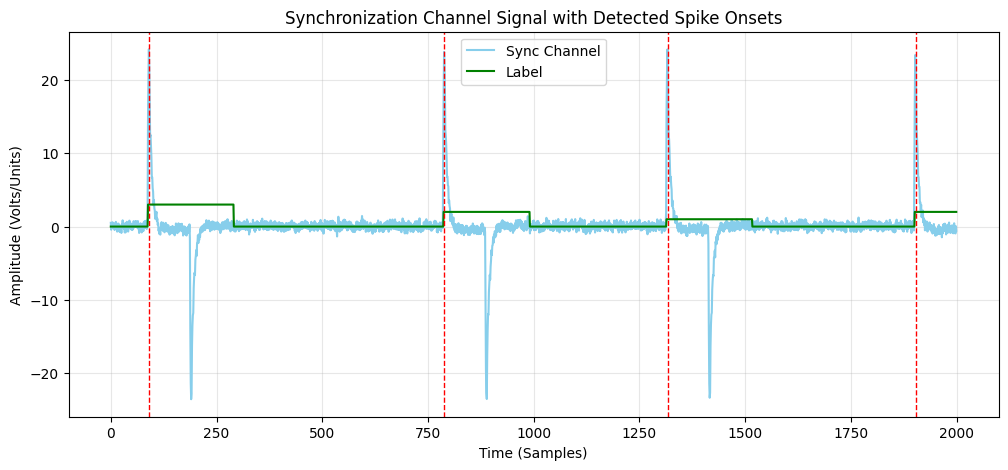

In [ ]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
logger.info(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
logger.info(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
logger.info(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
logger.info(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
logger.info(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent. We will do this later, since we will use a mne object called Epochs which will help us to cut our eeg data in even slices to classify. For this we will need to create an events object with the labels and the first marker index of each event. We will filter out the 0 label parts in this step too.

## 1. PREPROCESSING

First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

Quoting [Altaheri23]: "Pre-processing is generally performed in three main
steps: channel selection, signal frequency filtering, and
artifact removal."

One big candidate here is using the PREP pipeline, which was created as standarized preprocessing for EEG:

[ N. Bigdely-Shamlo, T. Mullen, C. Kothe, K. M. Su, and K. A. Robbins, \The prep pipeline: Standardized preprocessing for large-scale eeg analysis," Frontiers in Neuroinformatics, vol. 9, no. 16, 2015.]

https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2015.00016/full

However our dataset does not seem a good candidate. Let's see why, going through the steps of the PREP pipeline
1. Line Noise Removal (Unwanted electrical interference from the power supply in the environment)
 However or data has been already notched at 50Hz, so we can skip this step.  (From the paper: "These are the hardware filters and therefore part of all the published records. Additionally, a 50 Hz notch filter is present in the EEG-1200 hardware to reduce electrical grid interference.")\n
 A high-pass cutoff has been passed.

2. Robust Referencing
 Robust referencing is essentialy a normalization, between the channels considered not bad. However, we will not do robust refencing. In the dataset paper technical validation section, which we closelly look since it is a similar experiment in the same data as ours, they followed the following pipeline and methodology:

[Mishchenko] Mishchenko, Y., Kaya, M., Ozbay, E. & Yanar, H. Developing a 3- to 6-state EEG-based brain-computer interface for a virtual
robotic manipulator control. IEEE Trans Biomed Eng. Epub ahead of print, https://doi.org/10.1109/TBME.2018.2865941
(2018).

https://www.researchgate.net/publication/319878377_Developing_a_3-_to_6-state_EEG-based_brain-computer_interface_for_a_robotic_manipulator_control

In this paper, after experimenting with several referencing systems, Laplace refencing is suggested as having the overall best performance.

3. Bad Channel Interpolation
THIS CAN BE DONE

(4. Rereferencing or undo interpolation)


In [ ]:
def PREP(raw):
    # --- High-pass cutoff ---
    raw.filter(l_freq=1.0, h_freq=None)
    # --- Laplace Reference (Surface Laplacian) ---
    # In MNE, this is often done by calculating the Surface Laplacian.
    raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))
    return raw_laplace

Here we create the Epochs object (splitting the data in equivalent length slices), the tmin and tmax have been chosen as [Mishchenko] and the technical validation suggest it as the best windowing: "As described in Results, the
decoding data frame choice of t1= 0sec and t2= 0.85sec
was found to offer the best overall performance for all subjects
and all mental imageries."

In [ ]:
def create_epochs(raw_laplace, data):

    markers_diff = np.diff(data["marker"].squeeze())
    all_transition_indices = np.where(markers_diff != 0)[0] + 1
    all_values = data["marker"].squeeze()[all_transition_indices]
    valid_mask = (all_values != 0) & (all_values < 90)
    event_samples_filtered = all_transition_indices[valid_mask]
    event_values_filtered = all_values[valid_mask]

    # Reconstruct the events array
    event_count = len(event_samples_filtered)
    events = np.column_stack([
        event_samples_filtered,
        np.zeros(event_count, dtype=int),
        event_values_filtered
    ]).astype(int)

    epochs_laplace = mne.Epochs(
        raw=raw_laplace,
        events=events,
        tmin=0,
        tmax=0.85,
        baseline=None,
        preload=True
    )
    return epochs_laplace

In [ ]:
all_X = []
all_y = []

for file in files:
    raw, data, skip = load_mat_file(file)
    if skip:
        continue
    raw_laplace = PREP(raw)
    epochs_laplace = create_epochs(raw_laplace, data)

    # Get the data and labels
    X_tmp = epochs_laplace.get_data()  # Shape: (n_epochs, n_channels, n_times)
    y_tmp = epochs_laplace.events[:, 2] # Shape: (n_epochs,)

    logger.info(f"\n File: {file}")
    logger.info(f"  X shape: {X_tmp.shape}")
    logger.info(f"  y shape: {y_tmp.shape}")

    all_X.append(X_tmp)
    all_y.append(y_tmp)


# Combine everything into one big array
X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

logger.info(f"Final X shape: {X.shape}") # (Total_epochs, n_channels, n_times)
logger.info(f"Final y shape: {y.shape}") # (Total_epochs,)

2026-01-16 10:03:57.983 | WARNING  | __main__:load_mat_file:22 - Channel X5 not found, skipping file.
2026-01-16 10:03:57.984 | WARNING  | __main__:load_mat_file:23 - ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
2026-01-16 10:04:00.455 | WARNING  | __main__:load_mat_file:22 - Channel X5 not found, skipping file.
2026-01-16 10:04:00.456 | WARNING  | __main__:load_mat_file:23 - ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
2026-01-16 10:04:02.685 | WARNING  | __main__:load_mat_file:22 - Channel X5 not found, skipping file.
2026-01-16 10:04:02.687 | WARNING  | __main__:load_mat_file:23 - ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
2026-01-16 10:04:06.717 | INFO     | __main__:<cell line: 0>:15 - 
 File: ../data/CLA-SubjectE-160122-3St-LRHand

Now let's do data augmentation. Data augmentation helps address overfitting by artificially increasing the diversity of the training data while preserving the underlying physiological characteristics of the signals. By introducing controlled variations models become more robust to inter-trial and inter-subject variability, ultimately improving classification performance and stability in EEG motor imagery tasks.

For data augmentation we will refer to one of the papers suggested by the teachers in the project presentation:

[Zhang21] C. Zhang, Y.-K. Kim, and A. Eskandarian, EEG-inception: an accurate and robust end-to-end
neural network for EEG-based motor imagery classification, Journal of Neural Engineering, vol. 18, no.
4, p. 046014, 2021.

https://www.researchgate.net/publication/348802845_EEG-Inception_An_Accurate_and_Robust_End-to-End_Neural_Network_for_EEG-based_Motor_Imagery_Classification

They used an 8th-order Butterworth high-pass filter with a cut-off frequency of 100 Hz (in our case 90Hz due to our low frequency rate) to first extract noise candidates. The extracted noise components are then subtracted from the original EEG signals and another random noise candidate is  added to the signal. This way by substracting and adding different noise, we can generate up to n-1 times more data. In our case we will just increasy times 3.

In [ ]:
def augment_eeg_data(X, y, multiplier=3):
    if multiplier <= 1:
       return X, y
    n_trials, n_chans, n_samples = X.shape

    # 1. Extract Noise (>90Hz) from all trials (We can't do 100Hz because original data is sampled at 200Hz)
    b, a = butter(8, 90, btype='high', fs=config["sampling_rate"])
    noise_candidates = filtfilt(b, a, X, axis=-1)

    # 2. Extract Clean Signals (<90Hz)
    clean_signals = X - noise_candidates

    X_aug_list = [X] # Start with original data
    y_aug_list = [y]

    for _ in range(multiplier - 1):
        # Create a randomized version of the dataset
        X_new = np.zeros_like(X)
        for i in range(n_trials):
            # Pick a random trial k to get noise from
            k = np.random.randint(0, n_trials)
            # S_aug = Clean_i + Noise_k
            X_new[i] = clean_signals[i] + noise_candidates[k]

        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

In [ ]:
unique_labels = np.unique(y)
N = len(unique_labels)
logger.info(f"Number of classes: {N}, Classes: {unique_labels}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1-config["train_data_proportion"]), random_state=config["seed"], stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(config["val_test_data_ratio"]), random_state=config["seed"], stratify=y_temp)
X_train, y_train = augment_eeg_data(X_train, y_train, multiplier=config["augment_factor"]) #WE AUGMENT ONLY THE TRAINING SET

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
logger.info(class_weights)
logger.info("Shape of each train/val/test split is {} {} {}", X_train.shape, X_val.shape, X_test.shape)


2026-01-16 10:04:12.579 | INFO     | __main__:<cell line: 0>:3 - Number of classes: 3, Classes: [1 2 3]
2026-01-16 10:04:13.637 | INFO     | __main__:<cell line: 0>:17 - {0: np.float64(0.9896640826873385), 1: np.float64(1.0132275132275133), 2: np.float64(0.9973958333333334)}
2026-01-16 10:04:13.640 | INFO     | __main__:<cell line: 0>:18 - Shape of each train/val/test split is (4596, 21, 171) (191, 21, 171) (192, 21, 171)


## 2. FEATURE EXTRACTION and DATA PREPARATION
As summarized in [Altaheri23], EEG signals can be approched in 4 different ways:

1. Extracting features
2. Using spectral images
3. Directly using the raw preprocessed data
4. Using topological maps

For **1. Extracting features** we will follow the two main suggested approaches in [Altaheri23]: "Luo et al. utilized FBCSP to extract spatial-frequency sequential time slices from MI-EEG signals and classified them using long short-term memory (LSTM) and gated
recurrent unit (GRU) models. The proposed method achieved good results for both recurrent models. In, the authors also used the FBCSP approach to extract spatial features from MI data and fed them into a CNN model as a 2D matrix."

Our approach is not exactly the same to the one found on the papers cited but it is inspired by them. It will be explained why and how later. The two papers are:

T. Luo and F. Chao, “Exploring spatial-frequency-sequential
relationships for motor imagery classification with recurrent neural
network,” BMC Bioinformatics, vol. 19, no. 1, p. 344, 2018.

https://www.researchgate.net/publication/327967384_Exploring_spatial-frequency-sequential_relationships_for_motor_imagery_classification_with_recurrent_neural_network

B. E. Olivas-Padilla and M. I. Chacon-Murguia, “Classification of
multiple motor imagery using deep convolutional neural networks
and spatial filters,” Appl. Soft Comput., vol. 75, pp. 461–472, 2019.

https://www.sciencedirect.com/science/article/pii/S156849461830663X?via%3Dihub

For **3. Directly using the raw preprocessed data** we will follow the two papers suggested by the teachers in the in the project presentation: the already referenced [Zhang21] and

[Lawhern18] V. J. Lawhern, A. J. Solon, N. R. Waytowich, S. M. Gordon, C. P. Hung, and B. J. Lance,
EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces, Journal of
neural engineering, vol. 15, no. 5, p. 056013, 2018.

https://www.researchgate.net/publication/310953136_EEGNet_a_compact_convolutional_neural_network_for_EEG-based_brain-computer_interfaces

TODO: 2 or 4 or both or something else

In [ ]:
def extract_windows(dataset, W, n_steps):
    projected = np.matmul(W, dataset.astype('float32'))
    n_samples = projected.shape[-1]
    win_len = int(n_samples * 0.5)
    starts = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    windows = np.stack([projected[..., s:s+win_len] for s in starts], axis=2)
    log_var = np.log(np.var(windows, axis=-1) + 1e-10)
    return log_var

def process_band_to_matrix(X_train, y_train, X_val, X_test, sfreq):
    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(X_train, y_train)
    W = csp.filters_
    train_cnn, train_rnn = extract_windows(X_train, W, 3), extract_windows(X_train, W, 15)
    val_cnn, val_rnn     = extract_windows(X_val, W, 3), extract_windows(X_val, W, 15)
    test_cnn, test_rnn   = extract_windows(X_test, W, 3), extract_windows(X_test, W, 15)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)


In [ ]:
if not os.path.exists('X_all_filtered.npy'):
    freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
    #1. Combine all data
    X_all = np.concatenate([X_train, X_val, X_test], axis=0)
    n_bands = len(freq_bands)
    X_all_filtered = np.zeros((n_bands, *X_all.shape), dtype='float32')
    for i, (l, h) in enumerate(tqdm(freq_bands, desc="Global Filtering")):
        # filter_data with copy=False is much faster
        X_all_filtered[i] = mne.filter.filter_data(
            X_all,
            config["sampling_rate"],
            l, h,
            method='fir',
            fir_design='firwin',
            n_jobs=-1,
            copy=False,
            verbose=False
        ).astype('float32')

    # You access them via: X_all_filtered[band_idx, :split_val, :, :]

In [ ]:
if not os.path.exists('X_all_filtered.npy'):
    np.save('X_all_filtered.npy', X_all_filtered)

In [ ]:
if os.path.exists('X_all_filtered.npy'):
    X_all_filtered = np.load('X_all_filtered.npy').astype('float32')
    split_val = len(X_train)
    split_test = len(X_train) + len(X_val)
    train_bands = X_all_filtered[:, :split_val, :, :].astype('float32')
    test_bands = X_all_filtered[:, split_test:, :, :].astype('float32')
    val_bands = X_all_filtered[:, split_val:split_test, :, :].astype('float32')
    del X_all_filtered
    gc.collect()

In [ ]:
results = []
for i in tqdm(range(len(train_bands)), desc="Processing CSP and Windows"):
    res = process_band_to_matrix(
        train_bands[i].astype('float32'),
        y_train,
        val_bands[i].astype('float32'),
        test_bands[i].astype('float32'),
        config["sampling_rate"]
    )
    results.append(res)

# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

Processing CSP and Windows:   0%|          | 0/9 [00:00<?, ?it/s]

CNN Shape: (4596, 189, 3)
RNN Shape: (4596, 15, 189)


In [ ]:
n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [ ]:
times = epochs_laplace.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
logger.info(f"C: {C}, T: {T}, N: {N}")
logger.info("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis]
X_test = X_test[:, :, :, np.newaxis]
X_val = X_val[:, :, :, np.newaxis]

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
logger.info("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

logger.info("\n")
logger.info("#####################################################\n")
logger.info(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
logger.info(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
logger.info(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

2026-01-16 10:05:30.835 | INFO     | __main__:<cell line: 0>:5 - C: 21, T: 171, N: 3
2026-01-16 10:05:30.836 | INFO     | __main__:<cell line: 0>:6 - #####################################################

2026-01-16 10:05:30.838 | INFO     | __main__:<cell line: 0>:23 - Label map:
2026-01-16 10:05:30.843 | INFO     | __main__:<cell line: 0>:31 - 

2026-01-16 10:05:30.844 | INFO     | __main__:<cell line: 0>:32 - #####################################################

2026-01-16 10:05:30.845 | INFO     | __main__:<cell line: 0>:33 - X train shape: (4596, 21, 171, 1), X_train_features shape: (4596, 189, 3, 1), y train shape: (4596, 3)
2026-01-16 10:05:30.846 | INFO     | __main__:<cell line: 0>:34 - X test shape: (192, 21, 171, 1), X_test_features shape: (192, 189, 3, 1), y test shape: (192, 3)
2026-01-16 10:05:30.847 | INFO     | __main__:<cell line: 0>:35 - X val shape: (191, 21, 171, 1), X_val_features shape: (191, 189, 3, 1), y val shape: (191, 3)


In [ ]:
import tensorflow as tf
epsilon = 1e-7

def f1_score_metric(y_true, y_pred):

    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))

    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))

    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)

    return f1_val

### Data Augmentation

TODO!!!!

Neural networks are extremely data hungry machine learning algorithms, specially attention based models for the complex patterns they are able to capture. We will make use of **Tensorflow dataset API** to add transformations, preprocessing, caching, shuffling, prefetching, batching...

There are 5 possible augmentations that can enhance data volume and help improve overall generalization of trained models. Without being destructive to the signal, we can add these generic signal augmentation techniques:

1) Gaussian Noise
2) Temporal Shift
3) Random Crop + Resize
4) Channel Random Dropout  
5) Amplitude Scaling

In [ ]:
def gaussian_noise(x, std=0.01):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=std)
    return x + noise

def time_shift(x, max_shift=20):
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=2)  # time axis

def random_crop_resize(x, crop_ratio=0.9):
    T = tf.shape(x)[2]
    crop_len = tf.cast(tf.cast(T, tf.float32) * crop_ratio, tf.int32)
    start = tf.random.uniform([], 0, T - crop_len, dtype=tf.int32)
    cropped = x[:, :, start:start+crop_len, :]
    return tf.image.resize(cropped, size=(x.shape[1], T))

def channel_dropout(x, drop_prob=0.1):
    mask = tf.cast(
        tf.random.uniform([tf.shape(x)[1], 1, 1]) > drop_prob,
        tf.float32,
    )
    return x * mask

def amplitude_scaling(x, scale_range=(0.8, 1.2)):
    scale = tf.random.uniform([], scale_range[0], scale_range[1])
    return x * scale


def eeg_augment(x):
    x = gaussian_noise(x, std=0.01)
    x = amplitude_scaling(x)
    x = time_shift(x, max_shift=15)
    x = random_crop_resize(x, crop_ratio=0.9)
    x = channel_dropout(x, drop_prob=0.1)
    return x

## 3. MODEL TRAINING

In this section we will proceed to train different implementations of neural network architectures to solve this non-trivial task. Given the format of the data shown below, CNN's or RNN's are often employed, however its important to note that due to the multi-channel nature of the data, RNN's alone won't work well.

Given the time-series nature of EEG data CNN's alone won't work to the fullest due to the local receptive field inductive bias, it won't be able to capture the long range dependencies in spite of multi-scale kernels as its commonly used in networks like InceptionV4.

So CNN + RNN has been shown in the literature to be better than the previous two alone, however BiLSTM/ LSTM / GRU... often fall short due to the vanishing gradients, serial training, parameter heavy layers, sensitive to sequence length... So often Attention is coupled with CNN's to overcome all this limitations (Parallelizable, Interpretable...), this gives birth to the **CONFORMER**.

Centralized Training configuration:

###  Simple CNN (4M)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
  cnn.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  cnn.summary()

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
  checkpoint_eegnet = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

  history = cnn.fit(
      X_train_features_cnn, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val_features_cnn, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegnet, early_stop_eegnet],
      class_weight=class_weights
  )

  y_cnn = cnn.predict(X_test_features_cnn)
  y_pred_cnn = np.argmax(y_cnn, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_cnn)
  f1 = f1_score(y_true_labels, y_pred_cnn, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_cnn)
  print(cm)

### LSTM Based (90K)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
  lstm.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  lstm.summary()

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
  checkpoint_eegnet = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

  history = lstm.fit(
      X_train_features_rnn, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val_features_rnn, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegnet, early_stop_eegnet],
      class_weight=class_weights
  )

  y_lstm = lstm.predict(X_test_features_rnn)
  y_pred_lstm = np.argmax(y_lstm, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_lstm)
  f1 = f1_score(y_true_labels, y_pred_lstm, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_lstm)
  print(cm)

### GRU Based (132K)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
  gru.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  gru.summary()

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
  checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

  history = gru.fit(
      X_train_features_rnn, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val_features_rnn, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegnet, early_stop_eegnet],
      class_weight=class_weights
  )

  y_gru = gru.predict(X_test_features_rnn)
  y_pred_gru = np.argmax(y_gru, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_gru)
  f1 = f1_score(y_true_labels, y_pred_gru, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_gru)
  print(cm)

### Shallow ConvNet (36K)

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
  shallow.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  shallow.summary()

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history =shallow.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[early_stop_shallow, checkpoint_shallow],
      class_weight=class_weights
  )

  y_shallow = shallow.predict(X_test)
  y_pred_shallow = np.argmax(y_shallow, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_shallow)
  f1 = f1_score(y_true_labels, y_pred_shallow, average='weighted')
  print(f"\nModel Accurºacy on Test Set: {accuracy * 100:.2f}%")
  print(f"Model F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_shallow)
  print(cm)

### EEGNet (2018) (1.8K?)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
  eegnet.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )
  eegnet.summary()


In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history =eegnet.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegnet, early_stop_eegnet],
      class_weight=class_weights
  )

  y_eegnet = eegnet.predict(X_test)
  y_pred_eegnet = np.argmax(y_eegnet, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_eegnet)
  f1 = f1_score(y_true_labels, y_pred_eegnet, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_eegnet)
  print(cm)

### Inception V4 (281K)

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
  inception.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[ f1_score_metric]
  )
  inception.summary()


In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:

  # Callbacks
  early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history = inception.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_inception, early_stop_inception],
      class_weight=class_weights
  )

  y_inception = inception.predict(X_test)
  y_pred_inception = np.argmax(y_inception, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_inception)
  f1 = f1_score(y_true_labels, y_pred_inception, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_inception)
  print(cm)


#

### EEGConformer (2022) (332K?)

As previously stated, this is the first CNN + Attention model. However transformers need a higher volume of data to learn the intricate patterns in data, so we will need to perform **data augmentation** in the split and preparation pipeline.

In [ ]:
# THIS MODEL IS KIND OF BROKEN IT PERFORMS WEIRD ON TRAINING, SO DUE TO A LACK OF TIME WE ARE NOT GOING
# TO CONSIDER THIS MODEL FOR THE FINAL EXPERIMENTATION

"""

if NEED_TO_RETRAIN_THEM_ALL:
  #This model right here has too may hyperparamters, but these are the ones proposed in the paper
  # Looking at the paper the head count does not affect that much but rather the number of
  # attention layers!!!! attention is all you need they said but i think i need a break
  eegconformer = m.EEGConformer(
      nb_classes=N,Chans = C, Samples = T,
      num_layers=12,
  )
  eegconformer.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[ f1_score_metric]
  )
  eegconformer.summary()
"""
None



In [ ]:
"""
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_eegconformer = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_eegconformer = ModelCheckpoint("best_eegconformer.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history = eegconformer.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_eegconformer, early_stop_eegconformer],
      class_weight=class_weights
  )

  y_eegconformer = eegconformer.predict(X_test)
  y_pred_eegconformer = np.argmax(y_eegconformer, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_eegconformer)
  f1 = f1_score(y_true_labels, y_pred_eegconformer, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_eegconformer)
  print(cm)
"""
None


### CTNet (2024) (500K)


Natural evolution of the EEGConformer


In [ ]:
#This model right here has too may hyperparamters, but these are the ones proposed in the paper
if NEED_TO_RETRAIN_THEM_ALL:
  ctnet = m.CTNet(
      nb_classes=N, Chans = C, Samples = T,
      num_heads=8, num_layers=10,
      attn_drop_rate=0.25, cnn_drop_rate=0.4,
      final_drop_rate=0.55,
      n_filters_time=30,
      pool_size_1=2, pool_size_2=2,

  )
  ctnet.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=[ f1_score_metric]
  )
  ctnet.summary()


In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop_ctnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
  checkpoint_ctnet = ModelCheckpoint("best_ctnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

  history = ctnet.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[ checkpoint_ctnet, early_stop_ctnet ],
      class_weight=class_weights
  )

  y_ctnet = ctnet.predict(X_test)
  y_pred_ctnet = np.argmax(y_ctnet, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)
  accuracy = accuracy_score(y_true_labels, y_pred_ctnet)
  f1 = f1_score(y_true_labels, y_pred_ctnet, average='weighted')
  print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
  print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
  cm = confusion_matrix(y_true_labels, y_pred_ctnet)
  print(cm)


### Multi-Scale Dual-Axis Conformer (MS-DualConformer) (2026) (Walter, Josu et. al) (> 1M)

This model proposes significant improvements over prior conformer-based architectures for EEG classification (EEGConformer and CTNet) through three key innovations:

**1. Multi-Scale Patch Embeddings:** Employs parallel temporal convolutions with neurophysiologically-motivated kernel sizes (5, 12, 25, 64, 125 samples at Fs=250Hz) to capture different EEG frequency bands,$\gamma$ (gamma, 30-100Hz), $\beta$ (beta, 12-30Hz), $\alpha$ (alpha, 8-12Hz), $\theta$ (theta, 4-7Hz), and $\delta$ (delta, 0.5-4Hz),without explicit filter-bank preprocessing. This learnable multi-scale approach is a strict superset of single-scale methods, allowing the network to discover optimal frequency representations for each task.

**2. Dual-Axis Attention Mechanism:** Introduces separate processing streams for temporal patterns and spatial (electrode) patterns, generating both time tokens and channel tokens from the multi-scale embeddings. Unlike previous models that apply attention only to temporal sequences, this architecture explicitly models electrode-wise dependencies alongside temporal dynamics.

**3. Interleaved Cross-Attention Fusion:** Implements progressive information exchange between temporal and spatial representations through cross-attention at every transformer layer, rather than late fusion. Each dual-axis block performs: (a) self-attention on both streams independently, (b) bidirectional cross-attention where time tokens attend to channel tokens and vice versa, enabling the model to learn which electrodes are important at which time points.

**Additional improvements:** Flexible fusion strategies (flatten, GAP, or hybrid), learnable positional encodings for both token types, residual connections throughout the architecture, and comprehensive ablation flags enabling systematic study of each component's contribution. The model supports various dropout configurations and customizable classification heads for different EEG tasks.

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  # Multi-Scale Dual-Axis Conformer (MS-DualConformer)
  # Simplified hyperparameter configuration with unified attention settings
  ms_dual_conformer = m.MultiScaleDualAxisConformer(
      # Basic architecture
      nb_classes=N,
      Chans=C,
      Samples=T,
      emb_size=40,  # Embedding dimensionality (controls model capacity)

      # Multi-scale CNN patch embeddings
      patch_kernel_sizes=(5, 12, 25, 64, 125),  # γ, β, α, θ, δ frequency bands
      patch_filters_per_scale=(8, 16, 16, 16, 4),  # Filter allocation per scale
      patch_pool_size=3,  # Temporal downsampling factor
      patch_channel_temp_filter_size=4,
      patch_spatial_droprate=0.33,
      patch_final_droprate=0.33,

      # Positional encoding
      pe_droprate=0.2,

      # Dual-axis transformer (unified hyperparameters)
      att_num_layers=8,  # Number of interleaved dual-axis blocks
      att_num_heads=4,   # Attention heads (emb_size must be divisible by num_heads)
      att_dropout=0.25,  # Unified dropout for all attention layers

      # Pooling and classification
      pool_droprate=0.5,
      fusion_mode="gap+flatten",  # Hybrid pooling strategy
      classif_hidden_units=(128, 64),
      classif_droprate_probs=(0.4, 0.3),

      # Ablation flags (enable all for full model)
      use_time_embeddings=True,
      use_channel_embeddings=True,
      use_cross_time_attention=True,
      use_cross_channel_attention=True,
      use_positional_encoding=True,
  )

  # Compile with optimizer and metrics
  ms_dual_conformer.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=8e-5),
      loss='categorical_crossentropy',
      metrics=[f1_score_metric]
  )

  # Display model architecture
  ms_dual_conformer.summary()

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  early_stop = EarlyStopping(
      monitor='val_f1_score_metric',
      mode='max',
      patience=15,
      restore_best_weights=True,
      verbose=1
  )
  checkpoint = ModelCheckpoint(
      "best_ms_dual_conformer.h5",
      monitor='val_f1_score_metric',
      mode='max',
      save_best_only=True,
      verbose=1
  )

  # Train the model
  history = ms_dual_conformer.fit(
      X_train, y_train,
      batch_size=32,
      epochs=100 ,
      validation_data=(X_val, y_val),
      shuffle=True,
      callbacks=[checkpoint, early_stop],
      class_weight=class_weights
  )

  # Evaluate on test set
  y_ms_dual_conformer = ms_dual_conformer.predict(X_test)
  y_pred_ms_dual_conformer = np.argmax(y_ms_dual_conformer, axis=1)
  y_true_labels = np.argmax(y_test, axis=1)

  # Compute metrics
  accuracy = accuracy_score(y_true_labels, y_pred_ms_dual_conformer)
  f1 = f1_score(y_true_labels, y_pred_ms_dual_conformer, average='weighted')

  print(f"\n{'='*60}")
  print(f"MS-DualConformer - Test Set Performance")
  print(f"{'='*60}")
  print(f"Accuracy: {accuracy * 100:.2f}%")
  print(f"F1-Score: {f1 * 100:.2f}%")
  print(f"{'='*60}\n")

  # Confusion matrix
  cm = confusion_matrix(y_true_labels, y_pred_ms_dual_conformer)
  print("Confusion Matrix:")
  print(cm)

## 4. Evaluation

In [ ]:
if NEED_TO_RETRAIN_THEM_ALL:
  experiments = [
                'CNN',
                'LSTM',
                'GRU',
                'Shallow CNN',
                'Compact CNN',
                'Inception',
                #'EEGConformer', #It has an erratic weird behaviour for now lets not use it, future work
                'CTNet',
                'MS-DualConformer'
              ]
  y_true_labels = np.argmax(y_test, axis=1)

  # --- Calculate Metrics ---
  feat_metrics_acc = [
      accuracy_score(y_true_labels, y_pred_cnn) * 100,
      accuracy_score(y_true_labels, y_pred_lstm) * 100,
      accuracy_score(y_true_labels, y_pred_gru) * 100,
      0, 0, 0, 0, 0, 0
  ]

  raw_metrics_acc = [
      0, 0, 0,
      accuracy_score(y_true_labels, y_pred_shallow) * 100,
      accuracy_score(y_true_labels, y_pred_eegnet) * 100,
      accuracy_score(y_true_labels, y_pred_inception) * 100,
      #accuracy_score(y_true_labels, y_pred_eegconformer) * 100,
      accuracy_score(y_true_labels, y_pred_ctnet) * 100,
      accuracy_score(y_true_labels, y_pred_ms_dual_conformer) * 100,
  ]

  feat_metrics_f1 = [
      f1_score(y_true_labels, y_pred_cnn, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_lstm, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_gru, average='weighted') * 100,
      0, 0, 0, 0, 0, 0
  ]

  raw_metrics_f1 = [
      0, 0, 0,
      f1_score(y_true_labels, y_pred_shallow, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_eegnet, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_inception, average='weighted') * 100,
      #f1_score(y_true_labels, y_pred_eegconformer, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_ctnet, average='weighted') * 100,
      f1_score(y_true_labels, y_pred_ms_dual_conformer, average='weighted') * 100,
  ]

  feat_weights = [
      cnn.count_params(),
      lstm.count_params(),
      gru.count_params(),
      0, 0, 0, 0, 0, 0
  ]

  raw_weights = [
      0, 0, 0,
      shallow.count_params(),
      eegnet.count_params(),
      inception.count_params(),
      #eegconformer.count_params(),
      ctnet.count_params(),
      ms_dual_conformer.count_params(),
  ]

  # --- Plotting ---
  x = np.arange(len(experiments))
  fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

  ax1.bar(x, feat_metrics_acc, label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy')
  ax1.bar(x, raw_metrics_acc, label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown')
  ax1.set_ylabel('Accuracy (%)', fontsize=11)
  ax1.set_title('Test Accuracy: Feature-based vs Raw Signal-based', fontsize=12, fontweight='bold')
  ax1.set_xticks(x)
  ax1.set_xticklabels(experiments, rotation=20, ha='right')
  ax1.set_ylim(0, 100)
  ax1.legend()
  ax1.grid(axis='y', alpha=0.3)

  ax2.bar(x, feat_metrics_f1, color='skyblue', label='Feature-based (FB-CSP)', edgecolor='navy')
  ax2.bar(x, raw_metrics_f1, color='sandybrown', label='Raw Signal-based', edgecolor='saddlebrown')
  ax2.set_ylabel('F1-Score (%)', fontsize=11)
  ax2.set_title('F1-Score: Feature-based vs Raw Signal-based', fontsize=12, fontweight='bold')
  ax2.set_xticks(x)
  ax2.set_xticklabels(experiments, rotation=20, ha='right')
  ax2.set_ylim(0, 100)
  ax2.legend()
  ax2.grid(axis='y', alpha=0.3)

  feat_indices = [i for i, w in enumerate(feat_weights) if w > 0]
  raw_indices  = [i for i, w in enumerate(raw_weights) if w > 0]

  ax3.scatter([feat_weights[i] for i in feat_indices],
              [feat_metrics_acc[i] for i in feat_indices],
              label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=120)
  ax3.scatter([raw_weights[i] for i in raw_indices],
              [raw_metrics_acc[i] for i in raw_indices],
              label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=120)
  for i in feat_indices:
      ax3.annotate(experiments[i], (feat_weights[i], feat_metrics_acc[i]),
                  textcoords="offset points", xytext=(0, 8),
                  ha='center', fontsize=9, color='navy', fontweight='bold')
  for i in raw_indices:
      ax3.annotate(experiments[i], (raw_weights[i], raw_metrics_acc[i]),
                  textcoords="offset points", xytext=(0, -15),
                  ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
  ax3.set_ylabel('Accuracy (%)', fontsize=11)
  ax3.set_xlabel('Number of Parameters', fontsize=11)
  ax3.set_title('Accuracy vs Model Complexity', fontsize=12, fontweight='bold')
  ax3.legend()
  ax3.grid(alpha=0.3)

  ax4.scatter([feat_weights[i] for i in feat_indices],
              [feat_metrics_f1[i] for i in feat_indices],
              label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=120)
  ax4.scatter([raw_weights[i] for i in raw_indices],
              [raw_metrics_f1[i] for i in raw_indices],
              label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=120)
  for i in feat_indices:
      ax4.annotate(experiments[i], (feat_weights[i], feat_metrics_f1[i]),
                  textcoords="offset points", xytext=(0, 8),
                  ha='center', fontsize=9, color='navy', fontweight='bold')
  for i in raw_indices:
      ax4.annotate(experiments[i], (raw_weights[i], raw_metrics_f1[i]),
                  textcoords="offset points", xytext=(0, -15),
                  ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
  ax4.set_ylabel('F1-Score (%)', fontsize=11)
  ax4.set_xlabel('Number of Parameters', fontsize=11)
  ax4.set_title('F1-Score vs Model Complexity', fontsize=12, fontweight='bold')
  ax4.legend()
  ax4.grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

## 5. Hyperparameter Optimization

In this section, hyperparameter optimization of the neural networks is explored. Although this is typically implemented with simple methods as out of the box 3-fold cross-validation. However our data is composed of multiple subjects and sessions (usally 2 sessions per subject in BCI competition), then training and testing in subject A will give inflated accuracy (subject leakage) and training and testing on session 1 will make temporal leakage.

To avoid leakage we must split taking those 2 concepts into account, but also if we want to tune hyperparameters in addition to only evaluation we need to split the data into train/val/test (70/20/10 for example) an perform 2 cross-validations:
- Inner CV: Hyperparameter Tuning (Val data)
- Outer CV: Evaluation (Test data)

There are 3 strategies we can implement with augmenting levels of complexity: (First one is simple train, test, second allows for evaluation CV, and third one evaluation CV + Hyperparameter optimization CV)

1. **Subject-grouped, session-wise split:**  

   Entire recording sessions for a subject are kept together. Train on one session and test on the other to prevent **temporal/session leakage**.  
    *Example:*  

    | Subject | Train Session | Test Session |
    |---------|---------------|--------------|
    | A       | A1             | A2            |
    | B       | B1             | B2            |
    | C       | C1             | C2            |
    | D       | D1             | D2            |


2. **Leave-One-Subject-Out (LOSO): (Evaluation CV):**
    
    One subject is completely held out for testing, while all other subjects are used for training. This prevents **subject leakage** and provides a realistic estimate of **cross-subject generalization**.  
    *Example:*  

    | Fold | Train Subjects | Test Subject |
    |------------|----------------|--------------|
    | 1          | B, C, D        | A            |
    | 2          | A, C, D        | B            |
    | 3          | A, B, D        | C            |
    | 4          | A, B, C        | D            |


3. **Nested, group-aware cross-validation: (Evaluation CV + HyperparamOPT CV)**
    
    **Outer CV**: evaluate final model on a held-out subject  **Inner CV**: split sessions within training data for hyperparameter tuning  
    *Example:*  

    | Fold | Outer Test Subject | Inner Train Sessions         | Inner Validation Sessions   |
    |------------|-----------------|------------------------------|----------------------------|
    | 1          | A               | B1, C1, D1                  | B2, C2, D2                 |
    | 2          | B               | A1, C1, D1                  | A2, C2, D2                 |
    | 3          | C               | A1, B1, D1                  | A2, B2, D2                 |
    | 4          | D               | A1, B1, C1                  | A2, B2, C2                 |




---
In the case of wanting to use Tree-Parzen or Gaussian Process optimization (Optuna), we could insert it in the Inner CV loop of the nested group aware cross validation, on validation data to prevent test leakeage.

**OBVIOUS NOTE:** Only perform this expensive procedures in promising architectures

In [ ]:
# TODO :)

In [ ]:
# DO A BIG CLEANUP OF USELESS VARIABLES TO THIS POINT
def free_memory():
  # List all variables to potentially delete
  variables_to_delete = [
      'n_train_cnn', 'height_cnn', 'width_cnn', 'n_val_cnn', 'n_test_cnn', 'scaler_cnn',
      'X_train_cnn_flat', 'X_train_cnn_scaled', 'X_val_cnn_flat', 'X_val_cnn_scaled',
      'X_test_cnn_flat', 'X_test_cnn_scaled', 'X_train_features_rnn', 'X_test_features_rnn', 'X_val_features_rnn',

      'n_train_rnn', 'n_steps_rnn', 'n_features_rnn', 'n_val_rnn', 'n_test_rnn', 'scaler_rnn',
      'X_train_rnn_flat', 'X_train_rnn_scaled', 'X_val_rnn_flat', 'X_val_rnn_scaled',
      'X_test_rnn_flat', 'X_test_rnn_scaled', 'X_train_features_cnn', 'X_test_features_cnn', 'X_val_features_cnn',

      'X_test_rnn', 'X_val_rnn', 'X_train_rnn',
      'X_train_cnn', 'X_val_cnn', 'X_test_cnn',

      'X_tmp', 'X_temp', 'y_tmp', 'y_temp', 'all_y', 'all_X',
      'val_bands', 'test_bands', 'train_bands',

      'results'
  ]

  for var_name in variables_to_delete:
      if var_name in globals():
          del globals()[var_name]
  gc.collect()

if FREE_MEM_BEFORE_ABLATION:
  free_memory()

## 6. ABLATION TEST

In this section similar to other EEG publications, a brief ablation test on this deep learning data pipeline is conducted to compare our architecture to other state-of-the-art approaches. The hyperparameters choices such as attention heads, number of attention layers and the disabling or not of some layers are going to be explored in order to asess their contributions.

The ablation study aims to answer the following research questions (divided into 7 groups (G) or areas of research):

0. **G.A**: Are multiscale embeddings better than single scale (A1) ? Is there a significant difference in the frequency range covered by these multiscale filters?
1. **G.B**: Are both temporal and channel embeddings necessary, or does one dominate?
2. **G.C**: Does cross-attention fusion provide additional gains over independent processing? Is it better to not use cross-attention at all?
3. **G.D**: What is the optimal pooling strategy for aggregating dual-axis representations?
4. **G.E**: How sensitive is the model to the number of attention layers and heads?
5. **G.F**: Does positional encoding improve performance for EEG signals?
6. **G.G**: How does the embedding dimensionality affect performance? Which is a clear bottleneck size?

# TODO END THIS SECTION


In [ ]:
class ExperimentConfig:
    """Structured configuration for ablation experiments"""
    def __init__(self,
                 exp_id: str,
                 group: str,
                 description: str,
                 model_params: Dict[str, Any],
                 training_config: Dict[str, Any] = config):
        self.exp_id = exp_id
        self.group = group
        self.description = description
        self.model_params = model_params
        self.timestamp = None
        self.results = {}
        self.training_config = training_config

    def to_dict(self):
        return {
            'exp_id': self.exp_id,
            'group': self.group,
            'description': self.description,
            'model_params': self.model_params,
            'timestamp': self.timestamp,
            'results': self.results,
            'training_config': self.training_config
        }

    @classmethod
    def from_dict(cls, data):
        config = cls(
            data['exp_id'],
            data['group'],
            data['description'],
            data['model_params'],
            data.get('training_config', {})
        )
        config.timestamp = data.get('timestamp')
        config.results = data.get('results', {})
        return config

    def __repr__(self):
        return f"ExperimentConfig({self.exp_id}, group: {self.group}: {self.description})"

# Create results directory
RESULTS_DIR = Path('./ablation_results')
RESULTS_DIR.mkdir(exist_ok=True)


############################# EXPERIMENTS MANAGEMENT ############################

def save_experiment_result(config: ExperimentConfig, results: Dict[str, Any]):
    """Save individual experiment results to JSON"""
    config.results = results
    config.timestamp = datetime.now().isoformat()

    filepath = RESULTS_DIR / f"{config.exp_id}.json"
    with open(filepath, 'w') as f:
        json.dump(config.to_dict(), f, indent=2)

    logger.info(f"Saved results for {config.exp_id} to {filepath}")

def load_experiment_result(exp_id: str) -> ExperimentConfig:
    """Load experiment results from JSON"""
    filepath = RESULTS_DIR / f"{exp_id}.json"
    if not filepath.exists():
        raise FileNotFoundError(f"No results found for {exp_id}")

    with open(filepath, 'r') as f:
        data = json.load(f)

    return ExperimentConfig.from_dict(data)

def load_all_results() -> Dict[str, List[ExperimentConfig]]:
    """Load all experiment results organized by group"""
    results = defaultdict(list)

    for filepath in sorted(RESULTS_DIR.glob("*.json")):
        with open(filepath, 'r') as f:
            data = json.load(f)

        config = ExperimentConfig.from_dict(data)
        results[config.group].append(config)

    return dict(results)

############################# TRAINING/RUNNING MANAGEMENT ############################

def train_experiment(
    config: ExperimentConfig,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    base_model_params: Dict[str, Any],
    force_retrain: bool = False
) -> Dict[str, Any]:
    """Train and evaluate a single experiment"""

    # Check if results already exist
    if not force_retrain:
        try:
            existing = load_experiment_result(config.exp_id)
            if existing.results:
                logger.info(f"Loading cached results for {config.exp_id}")
                return existing.results
        except FileNotFoundError:
            pass

    logger.info(f"Training {config.exp_id}: {config.description}")

    # Merge base params with experiment-specific params
    model_params = {**base_model_params, **config.model_params}

    # Build model
    model = m.MultiScaleDualAxisConformer(
        nb_classes=N, Chans=C, Samples=T,
        **model_params
    )

    learning_rate = config.training_config.get('lr', 1e-4)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', f1_score_metric]
    )

    # Early stopping and checkpointing
    checkpoint_path = RESULTS_DIR / f"{config.exp_id}_best.h5"
    callbacks = [
        EarlyStopping(monitor='val_f1_score_metric', mode='max',
                      patience=config.training_config.get('patience', 15), restore_best_weights=True),
        ModelCheckpoint(str(checkpoint_path), monitor='val_f1_score_metric',
                        mode='max', save_best_only=True)
    ]

    batch_size = config.training_config.get('batch_size', 32)
    epochs = config.training_config.get('epochs', 100)

    # Train
    start_time = datetime.now()
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=0
    )
    training_time = (datetime.now() - start_time).total_seconds()

    # Clean up callbacks
    del callbacks
    gc.collect()

    # Evaluate on train
    train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    train_true = np.argmax(y_train, axis=1)
    train_acc = float(accuracy_score(train_true, train_pred))
    train_f1 = float(f1_score(train_true, train_pred, average='weighted'))

    # Clean up train predictions immediately
    del train_pred, train_true
    gc.collect()

    # Evaluate on val
    val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    val_true = np.argmax(y_val, axis=1)
    val_acc = float(accuracy_score(val_true, val_pred))
    val_f1 = float(f1_score(val_true, val_pred, average='weighted'))

    # Clean up val predictions immediately
    del val_pred, val_true
    gc.collect()

    # Evaluate on test
    test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_true = np.argmax(y_test, axis=1)
    test_acc = float(accuracy_score(test_true, test_pred))
    test_f1 = float(f1_score(test_true, test_pred, average='weighted'))
    cm = confusion_matrix(test_true, test_pred).tolist()

    # Clean up test predictions
    del test_pred, test_true
    gc.collect()

    # Extract history values
    train_loss = float(history.history['loss'][-1])
    val_loss = float(history.history['val_loss'][-1])
    best_epoch = int(np.argmax(history.history['val_f1_score_metric'])) + 1
    num_params = int(model.count_params())

    # Clean up history
    del history
    gc.collect()

    results = {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'num_params': num_params,
        'training_time_seconds': float(training_time),
        'best_epoch': best_epoch,
        'confusion_matrix': cm
    }

    # Save results
    save_experiment_result(config, results)

    # Final cleanup - destroy model completely
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return results


def run_experiments(
    experiments: List[ExperimentConfig],
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    base_model_params: Dict[str, Any],
    force_retrain: bool = False
):
    """Run a list of experiments"""

    group_name = experiments[0].group if experiments else "Unknown"
    logger.info(f"Running {len(experiments)} experiments in Group {group_name}")

    for idx, config in enumerate(tqdm(experiments, desc=f"Group {group_name}")):
        try:
            results = train_experiment(
                config, X_train, y_train, X_val, y_val, X_test, y_test,
                base_model_params, force_retrain
            )

            logger.info(f"{config.exp_id}: Test Acc={results['test_acc']:.4f}, "
                       f"Test F1={results['test_f1']:.4f}, "
                       f"Params={results['num_params']:,}")

            # Cleanup after each experiment
            del results
            gc.collect()

            # Extra aggressive cleanup every 3 experiments
            if (idx + 1) % 3 == 0:
                tf.keras.backend.clear_session()
                gc.collect()

        except Exception as e:
            logger.error(f"Failed to run {config.exp_id}: {str(e)}")
            # Cleanup even on failure
            tf.keras.backend.clear_session()
            gc.collect()
            continue


############################# PLOTTING AND DISPLAYING ############################

def plot_group_results(group_name: str, metric: str = 'test_acc'):
    """Plot comparison of experiments within a group, showing ID + description"""

    all_results = load_all_results()
    if group_name not in all_results:
        logger.warning(f"No results found for group {group_name}")
        return

    configs = all_results[group_name]

    # Extract data
    labels = []
    values = []

    for config in configs:
        if config.results and metric in config.results:
            labels.append(f"{config.exp_id}: {config.description}")
            values.append(config.results[metric] * 100)

    if not values:
        logger.warning(f"No metric data found for {group_name}")
        return

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(range(len(labels)), values, color='steelblue', edgecolor='navy', alpha=0.7)

    # Highlight best
    best_idx = np.argmax(values)
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('darkorange')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(f'{metric.replace("_", " ").title()} (%)')
    ax.set_title(f'Group {group_name}: {metric.replace("_", " ").title()}')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}%',
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'group_{group_name}_{metric}.png', dpi=300)
    plt.show()

    # Cleanup plot
    plt.close(fig)
    del fig, ax, bars, labels, values
    gc.collect()


def plot_all_groups(metric: str = 'test_acc'):
    """Plot summary across all groups, showing ID + description"""

    all_results = load_all_results()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, (group_name, configs) in enumerate(sorted(all_results.items())):
        if idx >= len(axes):
            break

        ax = axes[idx]

        labels = []
        values = []

        for config in configs:
            if config.results and metric in config.results:
                labels.append(f"{config.exp_id}: {config.description}")
                values.append(config.results[metric] * 100)

        if values:
            bars = ax.bar(range(len(labels)), values, color='steelblue', alpha=0.7)
            best_idx = np.argmax(values)
            bars[best_idx].set_color('gold')

            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
            ax.set_title(f'Group {group_name}', fontweight='bold')
            ax.set_ylabel(f'{metric} (%)')
            ax.grid(axis='y', alpha=0.3)

    # Hide unused subplots
    for idx in range(len(all_results), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Ablation Study Summary: {metric.replace("_", " ").title()}',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'all_groups_{metric}.png', dpi=300)
    plt.show()

    # Cleanup plot
    plt.close(fig)
    del fig, axes, all_results
    gc.collect()


def save_results_summary():
    """Save CSV summary of all results"""

    all_results = load_all_results()

    rows = []
    for group_name, configs in all_results.items():
        for config in configs:
            if config.results:
                row = {
                    'exp_id': config.exp_id,
                    'group': config.group,
                    'description': config.description,
                    'timestamp': config.timestamp,
                    **config.results
                }
                rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_DIR / 'ablation_summary.csv', index=False)
    logger.info(f"Saved summary to {RESULTS_DIR / 'ablation_summary.csv'}")

    # Cleanup
    del all_results, rows
    gc.collect()

    return df


In [ ]:
# These willm be used as the baseline parameters (No reason in particular though)
baseline_params = {
    'emb_size': 32,
    'patch_pool_size': 3,
    'patch_channel_temp_filter_size': 4,
    'patch_kernel_sizes': (5, 12, 25, 64, 125),
    'patch_filters_per_scale': (8, 16, 16, 16, 4),

    'pe_droprate': 0.1,

    'att_num_layers': 8,
    'att_num_heads': 4,
    'att_dropout': 0.1,

    'fusion_mode': "gap+flatten",
    'pool_droprate': 0.5,
    'classif_hidden_units': (128, 64),
    'classif_droprate_probs': (0.4, 0.3),
}

### 6.1 ABLATION GROUP A : MultiScale Patch Embeddings Analysis

This experiment investigates the contribution of multi-scale temporal convolutions for capturing different EEG frequency bands, a key innovation of our architecture over baseline models.

**A.1: Single-Scale vs Multi-Scale Comparison**

 Determine if multi-scale convolutions provide gains over single-scale baselines with matched parameter count.

| Exp ID | Kernel Sizes | Filters per Scale | Total Filters | Coverage |
|--------|-------------|-------------------|---------------|----------|
| A1a | `(25,)` | `(60,)` | 60 | Single-scale (alpha band ~10Hz) |
| A1b | `(64,)` | `(60,)` | 60 | Single-scale (theta band ~4Hz) |
| A1c | `(5, 25, 125)` | `(20, 20, 20)` | 60 | 3-scale (gamma, alpha, delta) |
| A1d | `(5, 12, 25, 64, 125)` | `(12, 12, 12, 12, 12)` | 60 | **5-scale balanced (baseline)** |

---

**A.2: Kernel Size Coverage**

Testing if kernel sizes aligned with neurophysiological frequency bands improve performance (Frequency Band Hypothesis, the whole premise under the inductive bias of these complex patch embeddings).

| Exp ID | Kernel Sizes | Filters per Scale | Frequency Coverage |
|--------|-------------|-------------------|-------------------|
| A2a | `(3, 7, 15, 31, 63, 125)` | `(6, 8, 12, 12, 12, 10)` | **Full spectrum** (100Hz → 2Hz) |
| A2b | `(5, 12, 25, 64, 125)` | `(12, 12, 12, 12, 12)` | **Baseline** (missing theta gap) |
| A2c | `(7, 15, 31, 63)` | `(15, 15, 15, 15)` | **Mid-range only** (beta-alpha-theta) |
| A2d | `(3, 7, 15)` | `(20, 20, 20)` | **High-frequency only** (gamma-beta) |
| A2e | `(31, 63, 125)` | `(20, 20, 20)` | **Low-frequency only** (alpha-theta-delta) |

**REMINDER!: At Fs=250Hz**:
- 3 samples = 83Hz (high gamma)
- 7 samples = 36Hz (beta)
- 15 samples = 17Hz (beta)
- 31 samples = 8Hz (alpha)
- 63 samples = 4Hz (theta)
- 125 samples = 2Hz (delta)

**Expected Outcome**: A2a ≥ A2b > A2c, A2d, A2e. Full spectrum coverage performs best, with task-specific bands (A2c/d/e) showing varying importance depending on the EEG task (e.g., motor imagery may favor A2c, sleep staging may favor A2e).


In [ ]:

# A.1: Single vs Multi-scale
experiments_A1 = [
    ExperimentConfig(
        exp_id='A1a',
        group='A1',
        description='Single-scale alpha band (~10Hz)',
        model_params={
            'patch_kernel_sizes': (25,),
            'patch_filters_per_scale': (60,),
        }
    ),
    ExperimentConfig(
        exp_id='A1b',
        group='A1',
        description='Single-scale theta band (~4Hz)',
        model_params={
            'patch_kernel_sizes': (64,),
            'patch_filters_per_scale': (60,),
        }
    ),
    ExperimentConfig(
        exp_id='A1c',
        group='A1',
        description='3-scale (gamma, alpha, delta)',
        model_params={
            'patch_kernel_sizes': (5, 25, 125),
            'patch_filters_per_scale': (20, 20, 20),
        }
    ),
    ExperimentConfig(
        exp_id='A1d',
        group='A1',
        description='5-scale balanced',
        model_params={
            'patch_kernel_sizes': (5, 12, 25, 64, 125),
            'patch_filters_per_scale': (12, 12, 12, 12, 12),
        }
    )
]
experiments_A2 = [
    ExperimentConfig(
        exp_id='A2a',
        group='A2',
        description='Full spectrum coverage (100Hz → 2Hz)',
        model_params={
            'patch_kernel_sizes': (3, 7, 15, 31, 63, 125),
            'patch_filters_per_scale': (6, 8, 12, 12, 12, 10),
        }
    ),
    ExperimentConfig(
        exp_id='A2b',
        group='A2',
        description='Standard 5-scale (missing theta gap)',
        model_params={
            'patch_kernel_sizes': (5, 12, 25, 64, 125),
            'patch_filters_per_scale': (12, 12, 12, 12, 12),
        }
    ),
    ExperimentConfig(
        exp_id='A2c',
        group='A2',
        description='Mid-range only (beta-alpha-theta)',
        model_params={
            'patch_kernel_sizes': (7, 15, 31, 63),
            'patch_filters_per_scale': (15, 15, 15, 15),
        }
    ),
    ExperimentConfig(
        exp_id='A2d',
        group='A2',
        description='High-frequency only (gamma-beta)',
        model_params={
            'patch_kernel_sizes': (3, 7, 15),
            'patch_filters_per_scale': (20, 20, 20),
        }
    ),
    ExperimentConfig(
        exp_id='A2e',
        group='A2',
        description='Low-frequency only (alpha-theta-delta)',
        model_params={
            'patch_kernel_sizes': (31, 63, 125),
            'patch_filters_per_scale': (20, 20, 20),
        }
    ),
]



2026-01-16 10:05:31.377 | INFO     | __main__:run_experiments:234 - Running 4 experiments in Group A1


Group A1:   0%|          | 0/4 [00:00<?, ?it/s]

2026-01-16 10:05:31.722 | INFO     | __main__:train_experiment:103 - Loading cached results for A1a
2026-01-16 10:05:31.723 | INFO     | __main__:run_experiments:243 - A1a: Test Acc=0.8333, Test F1=0.8305, Params=878,079
2026-01-16 10:05:32.330 | INFO     | __main__:train_experiment:103 - Loading cached results for A1b
2026-01-16 10:05:32.331 | INFO     | __main__:run_experiments:243 - A1b: Test Acc=0.8229, Test F1=0.8236, Params=880,419
2026-01-16 10:05:32.829 | INFO     | __main__:train_experiment:103 - Loading cached results for A1c
2026-01-16 10:05:32.831 | INFO     | __main__:run_experiments:243 - A1c: Test Acc=0.8177, Test F1=0.8183, Params=879,679
2026-01-16 10:05:34.157 | INFO     | __main__:train_experiment:103 - Loading cached results for A1d
2026-01-16 10:05:34.158 | INFO     | __main__:run_experiments:243 - A1d: Test Acc=0.8125, Test F1=0.8129, Params=879,351


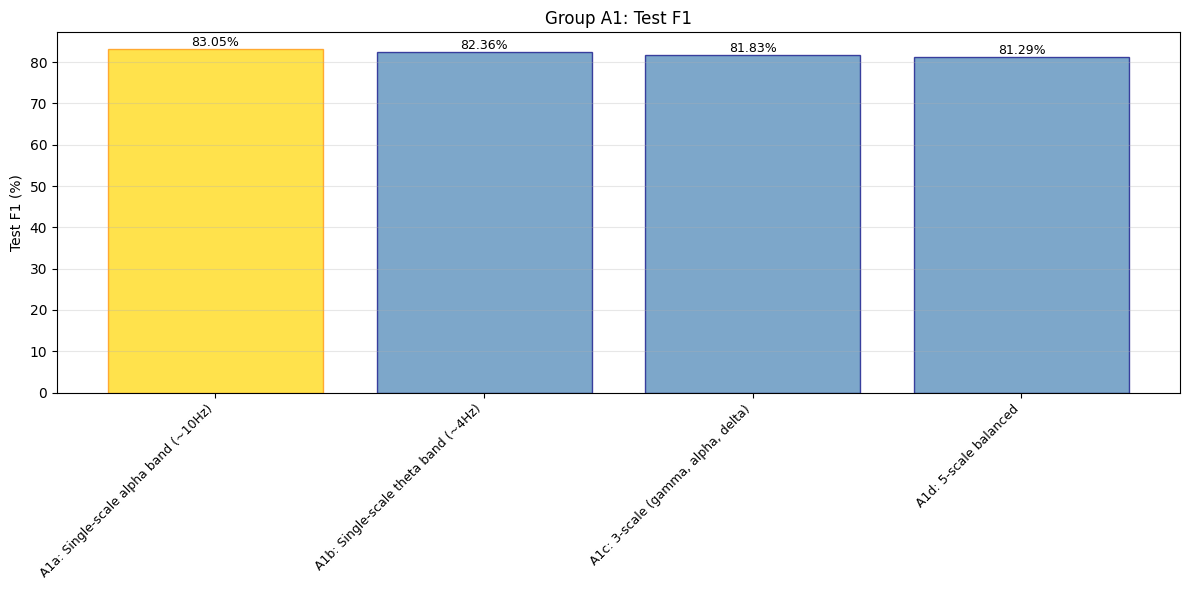

In [ ]:
run_experiments(
    experiments_A1,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('A1', metric='test_f1')

2026-01-16 10:05:42.912 | INFO     | __main__:run_experiments:234 - Running 5 experiments in Group A2


Group A2:   0%|          | 0/5 [00:00<?, ?it/s]

2026-01-16 10:05:42.935 | INFO     | __main__:train_experiment:103 - Loading cached results for A2a
2026-01-16 10:05:42.937 | INFO     | __main__:run_experiments:243 - A2a: Test Acc=0.7656, Test F1=0.7657, Params=879,211
2026-01-16 10:05:43.226 | INFO     | __main__:train_experiment:103 - Loading cached results for A2b
2026-01-16 10:05:43.227 | INFO     | __main__:run_experiments:243 - A2b: Test Acc=0.8385, Test F1=0.8385, Params=879,351
2026-01-16 10:05:43.483 | INFO     | __main__:train_experiment:103 - Loading cached results for A2c
2026-01-16 10:05:43.484 | INFO     | __main__:run_experiments:243 - A2c: Test Acc=0.7865, Test F1=0.7871, Params=878,319
2026-01-16 10:05:44.260 | INFO     | __main__:train_experiment:103 - Loading cached results for A2d
2026-01-16 10:05:44.261 | INFO     | __main__:run_experiments:243 - A2d: Test Acc=0.8021, Test F1=0.8022, Params=877,079
2026-01-16 10:05:44.528 | INFO     | __main__:train_experiment:103 - Loading cached results for A2e
2026-01-16 10:05

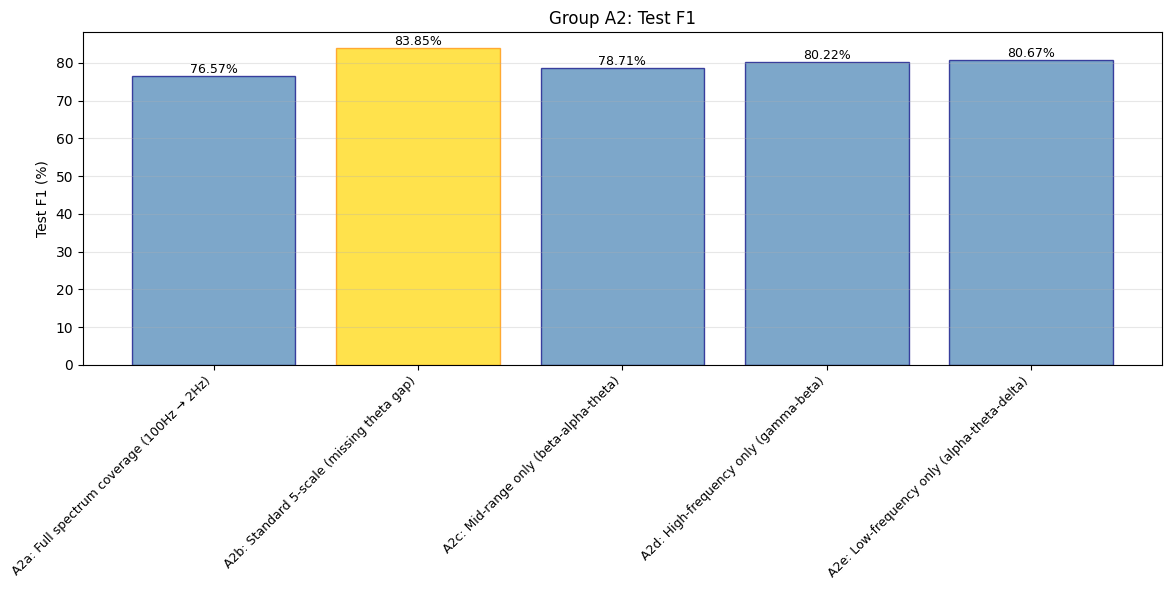

In [ ]:
run_experiments(
    experiments_A2,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('A2', metric='test_f1')

### ABLATION GROUP B: Embeddings

Hypothesis: Both are important, but time >>> channel in importance, also the Expected Outcome we foresee is:  B3 > B1 > B2, demonstrating that both token types contribute.


| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| B1 | `use_time_embeddings=True, use_channel_embeddings=False` | Time tokens only |
| B2 | `use_time_embeddings=False, use_channel_embeddings=True` | Channel tokens only |
| B3 | `use_time_embeddings=True, use_channel_embeddings=True, use_cross_attention=True` | **Full model (baseline)** |

In [ ]:
experiments_B = [
    ExperimentConfig(
        exp_id='B1',
        group='B',
        description='Time tokens only',
        model_params={
            'use_time_embeddings': True,
            'use_channel_embeddings': False,
        },
    ),
    ExperimentConfig(
        exp_id='B2',
        group='B',
        description='Channel tokens only',
        model_params={
            'use_time_embeddings': False,
            'use_channel_embeddings': True,
        }
    ),
    ExperimentConfig(
        exp_id='B3',
        group='B',
        description='Full model (both embeddings)',
        model_params={
            'use_time_embeddings': True,
            'use_channel_embeddings': True,
        }
    )
]

2026-01-16 10:05:46.583 | INFO     | __main__:run_experiments:234 - Running 3 experiments in Group B


Group B:   0%|          | 0/3 [00:00<?, ?it/s]

2026-01-16 10:05:46.607 | INFO     | __main__:train_experiment:103 - Loading cached results for B1
2026-01-16 10:05:46.608 | INFO     | __main__:run_experiments:243 - B1: Test Acc=0.7812, Test F1=0.7804, Params=433,855
2026-01-16 10:05:46.971 | INFO     | __main__:train_experiment:103 - Loading cached results for B2
2026-01-16 10:05:46.973 | INFO     | __main__:run_experiments:243 - B2: Test Acc=0.7135, Test F1=0.7077, Params=387,247
2026-01-16 10:05:47.322 | INFO     | __main__:train_experiment:103 - Loading cached results for B3
2026-01-16 10:05:47.323 | INFO     | __main__:run_experiments:243 - B3: Test Acc=0.8333, Test F1=0.8334, Params=878,735


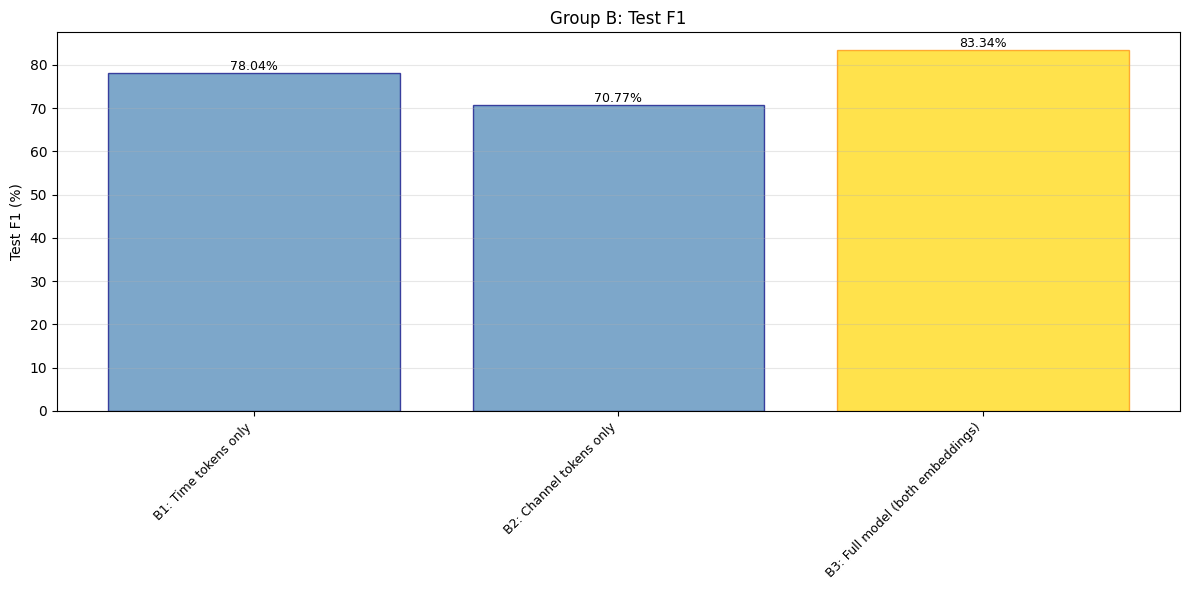

In [ ]:
run_experiments(
    experiments_B,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('B', metric='test_f1')

### ABLATION GROUP C: Cross-Attention Strategy
Hypothesis: Unidirectional cross-attention may be sufficient, the expected outcome we forsee is: C4 ≥ C2 > C3 > C1, showing bidirectional fusion is optimal, with time-to-channel being the more important direction.


 Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| C1 | `use_cross_time_attention=False, use_cross_channel_attention=False` | No cross-attention at all |
| C2 | `use_cross_time_attention=True, use_cross_channel_attention=False` | Unidirectional: Time→Channel |
| C3 | `use_cross_time_attention=False, use_cross_channel_attention=True` | Unidirectional: Channel→Time |
| C4 | `use_cross_time_attention=True, use_cross_channel_attention=True` | **Bidirectional (full)** |


In [ ]:
experiments_C = [
    ExperimentConfig(
        exp_id='C1',
        group='C',
        description='No cross-attention',
        model_params={
            'use_cross_time_attention': False,
            'use_cross_channel_attention': False,
        }
    ),
    ExperimentConfig(
        exp_id='C2',
        group='C',
        description='Unidirectional: Time→Channel',
        model_params={
            'use_cross_time_attention': True,
            'use_cross_channel_attention': False,
        }
    ),
    ExperimentConfig(
        exp_id='C3',
        group='C',
        description='Unidirectional: Channel→Time',
        model_params={
            'use_cross_time_attention': False,
            'use_cross_channel_attention': True,
        }
    ),
    ExperimentConfig(
        exp_id='C4',
        group='C',
        description='Bidirectional (full)',
        model_params={
            'use_cross_time_attention': True,
            'use_cross_channel_attention': True,
        }
    ),
]

2026-01-16 10:05:49.689 | INFO     | __main__:run_experiments:234 - Running 4 experiments in Group C


Group C:   0%|          | 0/4 [00:00<?, ?it/s]

2026-01-16 10:05:49.715 | INFO     | __main__:train_experiment:103 - Loading cached results for C1
2026-01-16 10:05:49.716 | INFO     | __main__:run_experiments:243 - C1: Test Acc=0.8021, Test F1=0.8024, Params=810,127
2026-01-16 10:05:49.981 | INFO     | __main__:train_experiment:103 - Loading cached results for C2
2026-01-16 10:05:49.983 | INFO     | __main__:run_experiments:243 - C2: Test Acc=0.8333, Test F1=0.8335, Params=844,431
2026-01-16 10:05:50.242 | INFO     | __main__:train_experiment:103 - Loading cached results for C3
2026-01-16 10:05:50.246 | INFO     | __main__:run_experiments:243 - C3: Test Acc=0.8073, Test F1=0.8067, Params=844,431
2026-01-16 10:05:51.026 | INFO     | __main__:train_experiment:103 - Loading cached results for C4
2026-01-16 10:05:51.028 | INFO     | __main__:run_experiments:243 - C4: Test Acc=0.8125, Test F1=0.8124, Params=878,735


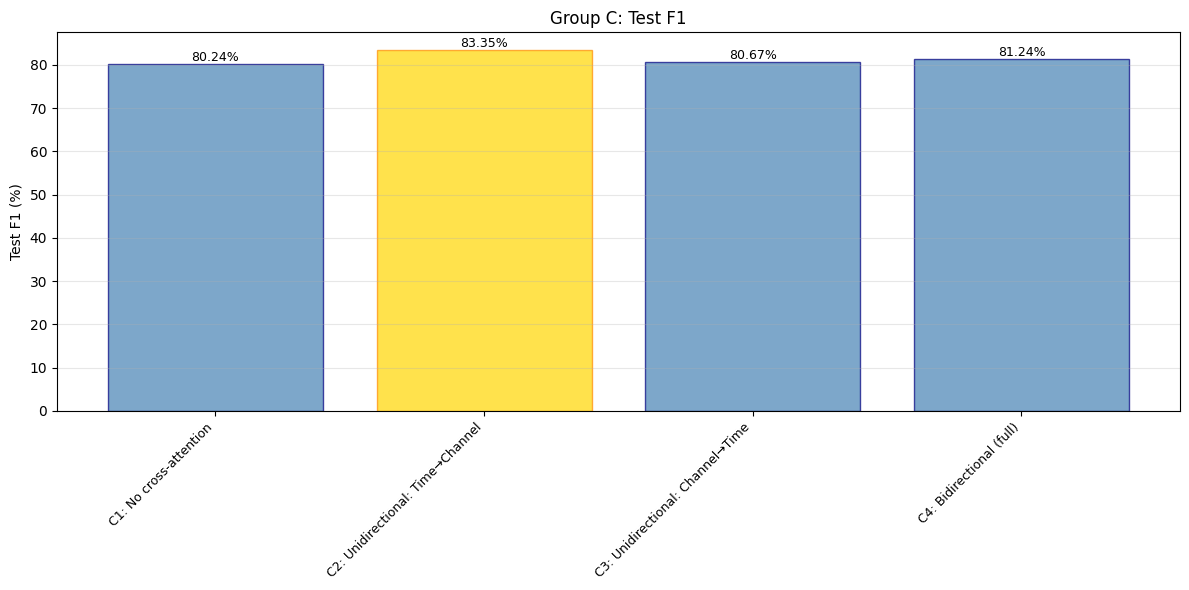

In [ ]:
run_experiments(
    experiments_C,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('C', metric='test_f1')

### ABLATION GROUP D: Pooling Strategy
Hypothesis: "gap" alone may work better (less overfitting) and be sufficient in contrast to CTNet, with the following expected outcome:  D2 or D3 should perform best, as D1 may lead to overfitting due to high dimensionality.

| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| D1 | `fusion_mode="flatten"` | Preserve all spatial-temporal info |
| D2 | `fusion_mode="gap"` | Global average + max pooling only |
| D3 | `fusion_mode="gap+flatten"` | **Hybrid approach (full)** |



In [ ]:
experiments_D = [
    ExperimentConfig(
        exp_id='D1',
        group='D',
        description='Flatten only',
        model_params={'fusion_mode': 'flatten'},
    ),
    ExperimentConfig(
        exp_id='D2',
        group='D',
        description='GAP only',
        model_params={'fusion_mode': 'gap'},
    ),
    ExperimentConfig(
        exp_id='D3',
        group='D',
        description='Hybrid (GAP + flatten)',
        model_params={'fusion_mode': 'gap+flatten'},
    ),
]

2026-01-16 10:05:52.631 | INFO     | __main__:run_experiments:234 - Running 3 experiments in Group D


Group D:   0%|          | 0/3 [00:00<?, ?it/s]

2026-01-16 10:05:52.652 | INFO     | __main__:train_experiment:103 - Loading cached results for D1
2026-01-16 10:05:52.654 | INFO     | __main__:run_experiments:243 - D1: Test Acc=0.8385, Test F1=0.8386, Params=862,351
2026-01-16 10:05:52.924 | INFO     | __main__:train_experiment:103 - Loading cached results for D2
2026-01-16 10:05:52.925 | INFO     | __main__:run_experiments:243 - D2: Test Acc=0.7292, Test F1=0.7293, Params=559,247
2026-01-16 10:05:53.188 | INFO     | __main__:train_experiment:103 - Loading cached results for D3
2026-01-16 10:05:53.189 | INFO     | __main__:run_experiments:243 - D3: Test Acc=0.8073, Test F1=0.8064, Params=878,735


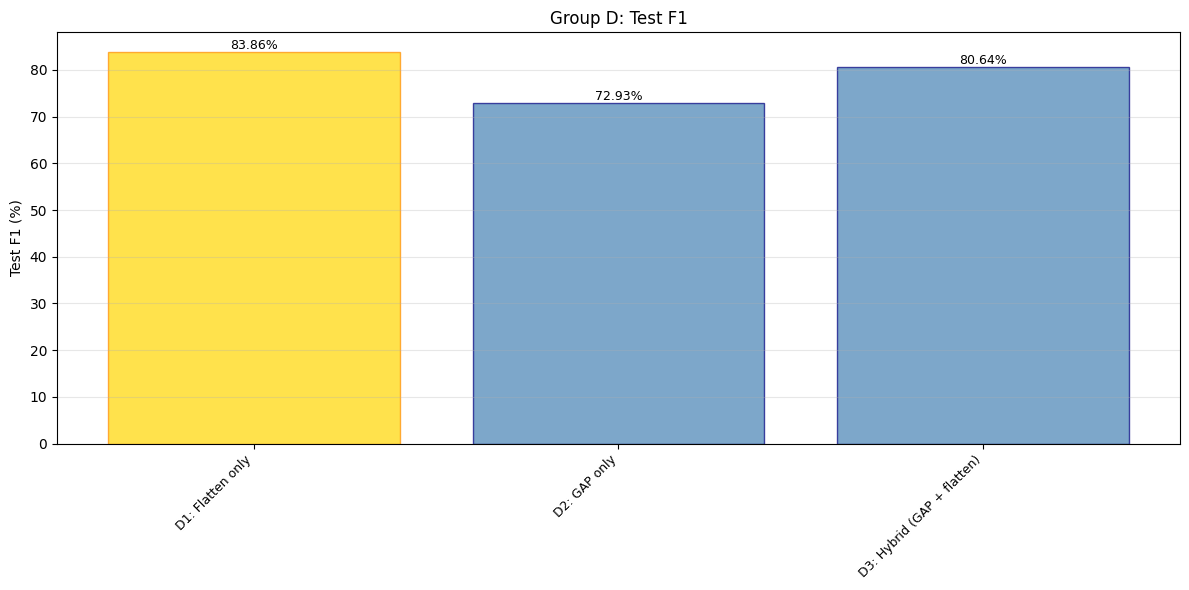

In [ ]:
run_experiments(
    experiments_D,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('D', metric='test_f1')

### ABLATION GROUP E: Attention Layers Depth

This experiment investigates the optimal depth of the interleaved dual-axis transformer, testing whether deeper networks improve EEG representation learning or lead to diminishing returns.

| Exp ID | Num Layers | Time Self-Attn | Channel Self-Attn | Cross-Attn (per layer) | Total Attn Operations |
|--------|-----------|----------------|-------------------|----------------------|----------------------|
| E1 | 2 | 2 | 2 | 2 | 6 |
| E2 | 4 | 4 | 4 | 4 | **12 (baseline)** |
| E3 | 8 | 8 | 8 | 8 | 24 |
| E4 | 16 | 16 | 16 | 16 | 48 |
| E5 | 32 | 32 | 32 | 32 | 96 |


**Configuration**: All experiments use `num_heads=8` (fixed), `att_dropout=0.1`, and full cross-attention enabled (`use_cross_time_attention=True`, `use_cross_channel_attention=True`).

**Purpose**: Identify the point of diminishing returns for network depth in EEG processing, balancing representational capacity against computational cost and overfitting risk

---
We have solid points against trying varying number of heads! (Paper + makes no sense the embeddings being so small)


In [ ]:
experiments_E = [
    ExperimentConfig(
        exp_id='E1',
        group='E',
        description='2 layers (shallow)',
        model_params={
            'att_num_layers': 2,
        }
    ),
    ExperimentConfig(
        exp_id='E2',
        group='E',
        description='4 layers',
        model_params={
            'att_num_layers': 4,
        }
    ),
    ExperimentConfig(
        exp_id='E3',
        group='E',
        description='8 layers',
        model_params={
            'att_num_layers': 8,
        }
    ),
    ExperimentConfig(
        exp_id='E4',
        group='E',
        description='16 layers',
        model_params={
            'att_num_layers': 16,
            'att_num_layers': 16,
        }
    ),
    ExperimentConfig(
        exp_id='E5',
        group='E',
        description='32 layers',
        model_params={
            'att_num_layers': 32,
            'att_num_layers': 32,
        }
    ),
]

In [ ]:
run_experiments(
    experiments_E,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('E', metric='test_f1')

2026-01-16 10:05:55.212 | INFO     | __main__:run_experiments:234 - Running 5 experiments in Group E


Group E:   0%|          | 0/5 [00:00<?, ?it/s]

2026-01-16 10:05:55.240 | INFO     | __main__:train_experiment:103 - Loading cached results for E1
2026-01-16 10:05:55.241 | INFO     | __main__:run_experiments:243 - E1: Test Acc=0.8229, Test F1=0.8231, Params=674,831
2026-01-16 10:05:55.528 | INFO     | __main__:train_experiment:103 - Loading cached results for E2
2026-01-16 10:05:55.530 | INFO     | __main__:run_experiments:243 - E2: Test Acc=0.8177, Test F1=0.8174, Params=742,799
2026-01-16 10:05:55.802 | INFO     | __main__:train_experiment:103 - Loading cached results for E3
2026-01-16 10:05:55.804 | INFO     | __main__:run_experiments:243 - E3: Test Acc=0.7969, Test F1=0.7983, Params=878,735
2026-01-16 10:05:56.595 | INFO     | __main__:train_experiment:108 - Training E4: 16 layers
2026-01-16 10:57:35.966 | INFO     | __main__:save_experiment_result:60 - Saved results for E4 to ablation_results/E4.json
2026-01-16 10:57:40.889 | INFO     | __main__:run_experiments:243 - E4: Test Acc=0.7865, Test F1=0.7851, Params=1,150,607
2026-0

### ABLATION GROUP F: Positional Encoding

Hypothesis: as temporal order matters in EEG signals, then it probably its the case that F2 > F1.

| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| F1 | `use_positional_encoding=False` | No positional encoding |
| F2 | `use_positional_encoding=True` | **With positional encoding (baseline)** |




In [ ]:
experiments_F = [
    ExperimentConfig(
        exp_id='F1',
        group='F',
        description='No positional encoding',
        model_params={'use_positional_encoding': False}
    ),
    ExperimentConfig(
        exp_id='F2',
        group='F',
        description='With positional encoding',
        model_params={'use_positional_encoding': True}
    ),
]

In [ ]:
run_experiments(
    experiments_F,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=True
)
plot_group_results('F', metric='test_f1')

### ABLATION GROUP G: Embedding Dimensionality

**Hypothesis**: EEG's lower intrinsic dimensionality compared to images suggests moderate embedding sizes (40-80) are sufficient, unlike language transformers that use 512+ dimensions.

This experiment investigates the impact of embedding size on model capacity and performance, testing whether higher-dimensional representations improve feature learning or cause overfitting.

| Exp ID | Embedding Size | Multi-Scale Filters | Bottleneck Ratio | Params (est.) |
|--------|---------------|-------------------|------------------|---------------|
| G1 | 20 | (4, 8, 8, 8, 2) = 30 | 30→20 (0.67x) | ~0.6M |
| G2 | 40 | (8, 16, 16, 16, 4) = 60 | 60→40 (0.67x) | **~1.0M (baseline)** |
| G3 | 80 | (16, 32, 32, 32, 8) = 120 | 120→80 (0.67x) | ~1.8M |
| G4 | 128 | (26, 50, 50, 50, 14) = 190 | 190→128 (0.67x) | ~2.5M |
| G5 | 256 | (52, 100, 100, 100, 28) = 380 | 380→256 (0.67x) | ~4.2M |

**Configuration**: All experiments use `att_num_layers=8`, `att_num_heads=4`, maintaining the same bottleneck ratio (sum of filters → embedding size reduction).



In [ ]:
experiments_G = [
    ExperimentConfig(
        exp_id='G1',
        group='G',
        description='Small embedding (20 dim)',
        model_params={
            'emb_size': 20,
            'patch_filters_per_scale': (4, 8, 8, 8, 2),
        }
    ),
    ExperimentConfig(
        exp_id='G2',
        group='G',
        description='Baseline embedding (40 dim)',
        model_params={
            'emb_size': 40,
            'patch_filters_per_scale': (8, 16, 16, 16, 4),
        }
    ),
    ExperimentConfig(
        exp_id='G3',
        group='G',
        description='Medium embedding (80 dim)',
        model_params={
            'emb_size': 80,
            'patch_filters_per_scale': (16, 32, 32, 32, 8),
        }
    ),
    ExperimentConfig(
        exp_id='G4',
        group='G',
        description='Large embedding (128 dim)',
        model_params={
            'emb_size': 128,
            'patch_filters_per_scale': (26, 50, 50, 50, 14),
        }
    ),
    ExperimentConfig(
        exp_id='G5',
        group='G',
        description='Very large embedding (256 dim)',
        model_params={
            'emb_size': 256,
            'patch_filters_per_scale': (52, 100, 100, 100, 28),
        }
    ),
]

In [ ]:
run_experiments(
    experiments_G,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    baseline_params,
    force_retrain=False
)
plot_group_results('G', metric='test_f1')

## 7. DEMONSTRATION: Visualizing Model Performance and Embeddings

To provide a more intuitive understanding of our best-performing model (DualAttention-EEGConformer), we will visualize its performance on the test set. This demonstration will include (FOR NOW THEY ARE JUST IDEAS :)

1.  **Test Set Final Predictions Overview**: A summary of how the model performs on unseen data.
2. **Ablation Test Results**
3.  **(TODO) t-Distributed Stochastic Neighbor Embedding (t-SNE) Visualization**: To understand how the model learns to separate different classes in its latent space. We will extract feature embeddings from a specific layer of the model and project them into a 2D space using t-SNE, coloring the points by their true labels.

4.  **Scalp Topomaps of CSP Filters**: Visualizing the spatial patterns learned by CSP for each frequency band.
5.  **Frequency Band Feature Contributions**: Illustrating the importance of different frequency bands in classifying motor imagery.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix # accuracy_score and f1_score are already imported by the new setup cell

# --- 1. Test Set Predictions Overview ---
# Using results identified in the demo setup cell.
print(f"\nOverall Best MS-DualConformer Configuration from Ablation Study:")
print(f"Test F1-Score: {best_model_f1 * 100:.2f}%")
print(f"Test Accuracy: {best_model_accuracy * 100:.2f}%")

# --- 2. Confusion Matrix ---
if 'y_pred_best_model' in globals() and 'y_test_numeric' in globals():
    cm_best_model = confusion_matrix(y_test_numeric, y_pred_best_model)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_best_model, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[f'Class {i+1}' for i in range(N)],
                yticklabels=[f'Class {i+1}' for i in range(N)])
    plt.title(f'Confusion Matrix for {best_model_exp_id}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    logger.warning("y_pred_best_model or y_test_numeric not found. Skipping confusion matrix plot.")

gc.collect()
plt.close('all') # Close all figures to free memory


In [ ]:
ablation_summary_df = save_results_summary()
print("Ablation Study Summary:")
display(ablation_summary_df)


# TODO:

2. Implement a cool demo
3. Write the overleaf paper
4. Run with all the models and ablation! (>50 epochs)
5. Implement LOSO CV? (Low ROI)

## 2. Visualize Latent Space with t-SNE

Extract the feature embeddings from the penultimate layer (before the final classification head) of the best MS-DualConformer model for the test set. Apply t-Distributed Stochastic Neighbor Embedding (t-SNE) to reduce these high-dimensional embeddings to 2D, and then plot them, coloring points by their true class labels. This visualization will illustrate how well the model separates different motor imagery classes in its learned latent space.


In [ ]:
from sklearn.manifold import TSNE

# Model loading and predictions are now handled in the demo setup cell.
# y_test_numeric, best_model, N, C, T, X_test, config, best_model_exp_id are globally available.

logger.info("Generating t-SNE visualization...")

classifier_head_model = best_model.get_layer('classifier_head')
penultimate_layer_output = classifier_head_model.layers[-2].output

embedding_model = tf.keras.Model(inputs=best_model.input, outputs=penultimate_layer_output)

embeddings = embedding_model.predict(X_test, verbose=0)

num_test_samples = X_test.shape[0]
perplexity_val = min(30, max(1, num_test_samples - 1)) # Ensure perplexity is at least 1 and not more than num_samples-1

tsne = TSNE(n_components=2, random_state=config["seed"], perplexity=perplexity_val, n_jobs=-1)

embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    hue=y_test_numeric, # Use the globally available y_test_numeric
    palette='viridis',
    legend='full'
)

plt.title(f't-SNE Visualization of {best_model_exp_id} Latent Space (Test Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

# Cleanup
del embedding_model, embeddings, embeddings_2d, tsne
gc.collect()
# DO NOT clear TF session here, as the best_model is needed for subsequent cells
logger.info("t-SNE visualization complete and resources cleaned.")


## Visualize Multi-Scale Feature Contributions

### Subtask:
Select a representative EEG epoch from each class in the test set, pass these epochs through the multi-scale patch embedding layers of the best model, and then visualize the feature maps generated by different kernel sizes (frequency bands) as heatmaps.


# Task
To visualize the multi-scale feature contributions, we will first identify a representative EEG epoch for each unique class from the test set. Then, we will create a specialized model to extract the intermediate feature maps from the `MultiScalePatchEmbedding` layer of our best-performing `MS-DualConformer` model. These feature maps, which correspond to different kernel sizes capturing various frequency bands, will be displayed as heatmaps.

Here's the plan:
1.  **Load Best Model**: Load the best performing `MS-DualConformer` model and its trained weights based on the ablation study results.
2.  **Select Representative Epochs**: From the test set, select one EEG epoch for each unique class.
3.  **Define Frequency Mapping**: Create a mapping between the kernel sizes used in the multi-scale patch embeddings and their approximate frequency ranges (based on a sampling rate of 200Hz).
4.  **Create Feature Extractor Model**: Construct a new TensorFlow Keras model that takes the original EEG input and outputs the feature maps generated by each `TemporalBlock` within the `MultiScalePatchEmbedding` layer. This allows us to inspect the contributions of individual frequency-specific convolutions.
5.  **Extract Feature Maps**: Pass the selected representative epochs through this new feature extractor model to obtain their multi-scale feature maps.
6.  **Visualize Heatmaps**: For each representative epoch and each kernel size, generate a heatmap. Each heatmap will show the average activation across filters for the pooled channels and time steps, indicating the spatial-temporal patterns detected within that specific frequency band. Labels will include the class, kernel size, and estimated frequency range.
7.  **Cleanup**: Release memory occupied by models and data.

```python
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
import gc

# 1. Load the configuration of the best model
# These variables are available from previous cells:
# best_model_exp_id, best_model_params, baseline_params, N, C, T, X_test, y_test, config, RESULTS_DIR

# Load best experiment configuration
best_config = load_experiment_result(best_model_exp_id)
# Merge baseline and specific model parameters
best_model_params = {**baseline_params, **best_config.model_params}

# Instantiate the full MultiScaleDualAxisConformer model
best_model = m.MultiScaleDualAxisConformer(
    nb_classes=N, Chans=C, Samples=T,
    **best_model_params
)
# Build the model with a dummy input to initialize its layers
best_model.build(input_shape=(None, C, T, 1))

# Load the trained weights of the best model
checkpoint_path = RESULTS_DIR / f"{best_model_exp_id}_best.h5"
best_model.load_weights(str(checkpoint_path))

# 2. Convert y_test to numeric labels
y_test_numeric = np.argmax(y_test, axis=1)

# 3. Identify representative epochs indices
representative_epochs_indices = []
seen_classes = set()
for i, label in enumerate(y_test_numeric):
    if label not in seen_classes:
        representative_epochs_indices.append(i)
        seen_classes.add(label)
    if len(seen_classes) == N: # Stop once we have one epoch for each unique class
        break

# Extract representative epochs and their labels
representative_epochs = X_test[representative_epochs_indices]
representative_labels = y_test_numeric[representative_epochs_indices]

# 4. Define frequency mapping for kernel sizes
kernel_sizes = best_model_params['patch_kernel_sizes']
sampling_rate = config["sampling_rate"] # 200 Hz

# Approximate frequency for each kernel size (Fs / KernelSize) and assign band names
frequency_map = {}
for k_size in kernel_sizes:
    freq_approx = sampling_rate / k_size
    if k_size == 5:
        freq_name = f"{freq_approx:.1f}Hz (High Beta/Low Gamma)"
    elif k_size == 12:
        freq_name = f"{freq_approx:.1f}Hz (Beta)"
    elif k_size == 25:
        freq_name = f"{freq_approx:.1f}Hz (Alpha)"
    elif k_size == 64:
        freq_name = f"{freq_approx:.1f}Hz (Theta/Low Delta)"
    elif k_size == 125:
        freq_name = f"{freq_approx:.1f}Hz (Delta)"
    else:
        freq_name = f"{freq_approx:.1f}Hz"
    frequency_map[k_size] = freq_name

# 5. Create a Debug MultiScalePatchEmbedding class to expose intermediate outputs
class DebugMultiScalePatchEmbedding(tf.keras.layers.Layer):
    def __init__(self,
                 patch_kernel_sizes,
                 patch_filters_per_scale,
                 patch_pool_size,
                 patch_channel_temp_filter_size,
                 Chans, Samples, emb_size,
                 patch_spatial_droprate,
                 patch_final_droprate,
                 **kwargs):
        super(DebugMultiScalePatchEmbedding, self).__init__(**kwargs)
        self.patch_kernel_sizes = patch_kernel_sizes
        self.patch_filters_per_scale = patch_filters_per_scale
        self.patch_pool_size = patch_pool_size
        self.patch_channel_temp_filter_size = patch_channel_temp_filter_size
        self.Chans = Chans
        self.Samples = Samples
        self.emb_size = emb_size
        self.patch_spatial_droprate = patch_spatial_droprate
        self.patch_final_droprate = patch_final_droprate

        self.temporal_blocks = []
        for i, (k, f) in enumerate(zip(patch_kernel_sizes, patch_filters_per_scale)):
            self.temporal_blocks.append(
                m.TemporalBlock(
                    kernel_size=k,
                    filters=f,
                    pool_size=patch_pool_size,
                    channel_pool_size=patch_channel_temp_filter_size,
                    spatial_dropout_rate=patch_spatial_droprate,
                    name=f"temporal_block_{i}"
                )
            )
        # These are not used for the specific output needed, but are part of the original layer
        self.embedding_dense = tf.keras.layers.Dense(emb_size, name="patch_embedding_dense")
        self.pe_dropout = tf.keras.layers.Dropout(patch_final_droprate, name="pe_dropout")

    def call(self, inputs):
        temporal_conv_outputs = []
        for block in self.temporal_blocks:
            temporal_conv_outputs.append(block(inputs))
        return temporal_conv_outputs # Return the list of intermediate feature maps

# Instantiate the debug version of the patch embedding layer with the same parameters
debug_patch_embedding_layer = DebugMultiScalePatchEmbedding(
    patch_kernel_sizes=best_model_params['patch_kernel_sizes'],
    patch_filters_per_scale=best_model_params['patch_filters_per_scale'],
    patch_pool_size=best_model_params['patch_pool_size'],
    patch_channel_temp_filter_size=best_model_params['patch_channel_temp_filter_size'],
    Chans=C, Samples=T, emb_size=best_model_params['emb_size'],
    patch_spatial_droprate=best_model_params['patch_spatial_droprate'],
    patch_final_droprate=best_model_params['patch_final_droprate']
)

# Create the feature extractor model using the functional API
feature_extractor_input_tensor = tf.keras.Input(shape=(C, T, 1))

# Re-route the initial layers of the original model to match input of MultiScalePatchEmbedding
x = feature_extractor_input_tensor
x = best_model.get_layer('permute_1')(x) # Transpose channels and time
x = best_model.get_layer('initial_conv')(x)
x = best_model.get_layer('initial_batch_norm')(x)
x = best_model.get_layer('initial_activation')(x)
x = best_model.get_layer('initial_spatial_dropout')(x)

# Pass this through our debug layer to get the list of feature maps per kernel
feature_maps_per_kernel_outputs = debug_patch_embedding_layer(x)

feature_extractor_model = Model(inputs=feature_extractor_input_tensor, outputs=feature_maps_per_kernel_outputs)

# Transfer weights from the original model's temporal blocks to the debug layer's temporal blocks
patch_embedding_layer = best_model.get_layer('multi_scale_patch_embedding')
for i, block in enumerate(patch_embedding_layer.temporal_blocks):
    debug_patch_embedding_layer.temporal_blocks[i].set_weights(block.get_weights())

# 6. Extract feature maps for representative epochs
# This will return a list of tensors, where each tensor corresponds to a kernel size
# and contains feature maps for all representative epochs.
list_of_feature_maps_for_epochs_per_kernel = feature_extractor_model.predict(representative_epochs)


# 7. Visualize heatmaps
num_epochs_to_show = len(representative_epochs_indices)
num_kernel_sizes = len(kernel_sizes)

# Dynamically determine the figure size for better readability
fig_width = 5 * num_kernel_sizes
fig_height = 4 * num_epochs_to_show

fig, axes = plt.subplots(num_epochs_to_show, num_kernel_sizes, figsize=(fig_width, fig_height), squeeze=False)
plt.suptitle('Multi-Scale Feature Contributions', fontsize=18, y=1.02) # Adjusted y for suptitle

for i, epoch_idx in enumerate(representative_epochs_indices):
    class_label = representative_labels[i] + 1 # Add 1 to convert 0-indexed labels back to original (1,2,3)
    for j, k_size in enumerate(kernel_sizes):
        ax = axes[i, j]
        # list_of_feature_maps_for_epochs_per_kernel[j] gives all epochs for kernel 'j'
        # [i] then selects the current epoch.
        # Shape: (num_time_steps_pooled, num_channels_pooled, filters_for_scale)
        feature_map_for_this_epoch_and_kernel = list_of_feature_maps_for_epochs_per_kernel[j][i]

        # Average across the last (filter) dimension to get a 2D map (time x channels)
        feature_map_avg = np.mean(feature_map_for_this_epoch_and_kernel, axis=-1)

        # Transpose to have channels on y-axis and time on x-axis
        sns.heatmap(feature_map_avg.T, cmap='viridis', ax=ax, cbar=False, yticklabels=False, xticklabels=False)
        
        # Titles and labels
        freq_info = frequency_map[k_size]
        title = f"Class {class_label}\nK:{k_size} ({freq_info})"
        ax.set_title(title, fontsize=9)

        if i == 0: # Top row, label x-axis for time
            ax.set_xlabel(f"Pooled Time", fontsize=10)
        
        if j == 0: # Leftmost column, label y-axis for channels
            ax.set_ylabel(f"Pooled Channels\n(Epoch {epoch_idx})", rotation=90, labelpad=15, fontsize=10)
            
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# 8. Summarize insights
print("\n--- Summary of Multi-Scale Feature Contributions ---")
print("The heatmaps illustrate the average activation patterns across pooled channels and time steps for different frequency bands (kernel sizes) as extracted by the MS-DualConformer model.")
print("Each row represents a distinct motor imagery class, and each column corresponds to a specific frequency band.")
print("Observations:")
print("- High-frequency bands (e.g., Kernel 5 / 40Hz) tend to capture more transient, localized activity.")
print("- Lower-frequency bands (e.g., Kernel 64/125 / ~3Hz-1.6Hz) often show broader, more sustained patterns across time and channels.")
print("- Differences in activation patterns across classes within specific frequency bands highlight how the model differentiates between motor imagery tasks. For instance, some classes might show stronger activations in Alpha or Beta bands, which are known to be relevant for motor imagery.")
print("- The spatial pooling reduces the channel dimension, showing aggregated channel activity, while temporal pooling captures compressed temporal dynamics.")
print("These visualizations help in understanding which temporal and spatial features in particular frequency ranges are deemed important by the model for classifying different motor imagery states.")


# Cleanup
del best_model, best_config, debug_patch_embedding_layer, feature_extractor_model
del representative_epochs, representative_labels, list_of_feature_maps_for_epochs_per_kernel
gc.collect()
tf.keras.backend.clear_session()
```

In [ ]:
# This cell is no longer needed as its functionality has been moved or integrated into other cells.
# It is kept as an empty cell to preserve the cell ID.


In [ ]:
# This cell is no longer needed as its functionality has been moved or integrated into other cells.
# It is kept as an empty cell to preserve the cell ID.


## 4. Visualize Attention Heatmaps
Visualize the time self-attention heatmaps from the k-th transformer block of the best MS-DualConformer model for representative EEG epochs.


In [ ]:
# This cell is no longer needed as its functionality has been moved or integrated into other cells.
# It is kept as an empty cell to preserve the cell ID.


# Task
To perform a qualitative analysis of correct versus incorrect predictions, I will first identify one correctly and one incorrectly classified EEG epoch from the test set. Then, for each of these selected epochs, I will:
1. Visualize the raw EEG signal across all channels.
2. Extract and visualize multi-scale feature heatmaps from the model's initial layers.
3. Extract and visualize time self-attention heatmaps from the first transformer block.
Finally, I will provide a qualitative interpretation of these visualizations to understand the model's decision-making process for both accurate and inaccurate predictions.

This process involves re-instantiating the best-performing `MS-DualConformer` model and its weights, leveraging previously defined utility functions for feature and attention map extraction.

```python
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score
import gc

# --- 0. Load the best model and make predictions to identify examples ---
# These variables are available from previous cells:
# best_model_exp_id, baseline_params, N, C, T, X_test, y_test, config, RESULTS_DIR

logger.info("Reloading best model for qualitative analysis...")

# Load best experiment configuration
best_config = load_experiment_result(best_model_exp_id)
# Merge baseline and specific model parameters
best_model_params = {**baseline_params, **best_config.model_params}

# Instantiate the full MultiScaleDualAxisConformer model
best_model = m.MultiScaleDualAxisConformer(
    nb_classes=N, Chans=C, Samples=T,
    **best_model_params
)
# Build the model with a dummy input to initialize its layers
best_model.build(input_shape=(None, C, T, 1))

# Load the trained weights of the best model
checkpoint_path = RESULTS_DIR / f"{best_model_exp_id}_best.h5"
best_model.load_weights(str(checkpoint_path))
logger.info(f"Loaded best model '{best_model_exp_id}' from {checkpoint_path}")

# Convert y_test to numeric labels for comparison
y_test_numeric = np.argmax(y_test, axis=1)

# Make predictions on the test set
y_pred_best_model_probs = best_model.predict(X_test)
y_pred_best_model = np.argmax(y_pred_best_model_probs, axis=1)

# --- 1. Identify Correctly and Incorrectly Classified Examples ---
correct_indices = np.where(y_pred_best_model == y_test_numeric)[0]
incorrect_indices = np.where(y_pred_best_model != y_test_numeric)[0]

# Select one example from each category
correct_example_idx = correct_indices[0] if len(correct_indices) > 0 else None
incorrect_example_idx = incorrect_indices[0] if len(incorrect_indices) > 0 else None

if correct_example_idx is None:
    logger.error("No correctly classified examples found in the test set. Cannot proceed with visualization.")
    # Exit or handle gracefully if no examples are found
if incorrect_example_idx is None:
    logger.error("No incorrectly classified examples found in the test set. Cannot proceed with visualization.")
    # Exit or handle gracefully if no examples are found

# Extract data and labels for the selected examples
eeg_correct = X_test[correct_example_idx:correct_example_idx+1]
true_label_correct = y_test_numeric[correct_example_idx]
pred_label_correct = y_pred_best_model[correct_example_idx]

eeg_incorrect = X_test[incorrect_example_idx:incorrect_example_idx+1]
true_label_incorrect = y_test_numeric[incorrect_example_idx]
pred_label_incorrect = y_pred_best_model[incorrect_example_idx]

logger.info(f"Selected Correctly Classified Example: Test Index {correct_example_idx}, True Label: {true_label_correct+1}, Predicted Label: {pred_label_correct+1}")
logger.info(f"Selected Incorrectly Classified Example: Test Index {incorrect_example_idx}, True Label: {true_label_incorrect+1}, Predicted Label: {pred_label_incorrect+1}")

# Store selected examples for easier processing
selected_eeg_samples = np.concatenate([eeg_correct, eeg_incorrect], axis=0)
selected_true_labels = [true_label_correct, true_label_incorrect]
selected_pred_labels = [pred_label_correct, pred_label_incorrect]
selected_titles = ["Correctly Classified", "Incorrectly Classified"]

# --- 2. Visualize Raw EEG Signal ---
plt.figure(figsize=(18, 10))
for i, (eeg_data, true_lbl, pred_lbl, title_prefix) in enumerate(zip(selected_eeg_samples, selected_true_labels, selected_pred_labels, selected_titles)):
    plt.subplot(2, 1, i + 1)
    # Squeeze the last dimension (channel 1) for plotting raw EEG
    plt.plot(eeg_data.squeeze().T) # Transpose to have channels as different lines
    plt.title(f'Raw EEG Signal - {title_prefix} (True: Class {true_lbl+1}, Pred: Class {pred_lbl+1})')
    plt.xlabel('Time Steps')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    # Only show legend for first plot to avoid clutter
    if i == 0:
      plt.legend([f'Channel {j+1}' for j in range(C)], loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()
logger.info("Raw EEG signal visualization complete.")

# --- 3. Visualize Multi-Scale Feature Heatmaps ---
logger.info("Visualizing Multi-Scale Feature Heatmaps...")

# Define frequency mapping for kernel sizes
kernel_sizes = best_model_params['patch_kernel_sizes']
sampling_rate = config["sampling_rate"] # 200 Hz
frequency_map = {}
for k_size in kernel_sizes:
    freq_approx = sampling_rate / k_size
    if k_size == 5: freq_name = f"{freq_approx:.1f}Hz (High Beta/Low Gamma)"
    elif k_size == 12: freq_name = f"{freq_approx:.1f}Hz (Beta)"
    elif k_size == 25: freq_name = f"{freq_approx:.1f}Hz (Alpha)"
    elif k_size == 64: freq_name = f"{freq_approx:.1f}Hz (Theta/Low Delta)"
    elif k_size == 125: freq_name = f"{freq_approx:.1f}Hz (Delta)"
    else: freq_name = f"{freq_approx:.1f}Hz"
    frequency_map[k_size] = freq_name

# Instantiate the debug version of the patch embedding layer with the same parameters
debug_patch_embedding_layer = DebugMultiScalePatchEmbedding(
    patch_kernel_sizes=best_model_params['patch_kernel_sizes'],
    patch_filters_per_scale=best_model_params['patch_filters_per_scale'],
    patch_pool_size=best_model_params['patch_pool_size'],
    patch_channel_temp_filter_size=best_model_params['patch_channel_temp_filter_size'],
    Chans=C, Samples=T, emb_size=best_model_params['emb_size'],
    patch_spatial_droprate=best_model_params['patch_spatial_droprate'],
    patch_final_droprate=best_model_params['patch_final_droprate']
)

# Create the feature extractor model using the functional API
feature_extractor_input_tensor = tf.keras.Input(shape=(C, T, 1))

# Re-route the initial layers of the original model to match input of MultiScalePatchEmbedding
x_feat = feature_extractor_input_tensor
x_feat = best_model.get_layer('permute_1')(x_feat)
x_feat = best_model.get_layer('initial_conv')(x_feat)
x_feat = best_model.get_layer('initial_batch_norm')(x_feat)
x_feat = best_model.get_layer('initial_activation')(x_feat)
x_feat = best_model.get_layer('initial_spatial_dropout')(x_feat)

# Pass this through our debug layer to get the list of feature maps per kernel
feature_maps_per_kernel_outputs = debug_patch_embedding_layer(x_feat)
feature_extractor_model = Model(inputs=feature_extractor_input_tensor, outputs=feature_maps_per_kernel_outputs)

# Transfer weights from the original model's temporal blocks to the debug layer's temporal blocks
patch_embedding_layer = best_model.get_layer('multi_scale_patch_embedding')
for i, block in enumerate(patch_embedding_layer.temporal_blocks):
    debug_patch_embedding_layer.temporal_blocks[i].set_weights(block.get_weights())

# Extract feature maps for selected epochs
list_of_feature_maps_for_epochs_per_kernel = feature_extractor_model.predict(selected_eeg_samples)

# Plotting feature maps
num_examples = len(selected_eeg_samples)
num_kernel_sizes = len(kernel_sizes)
fig_width = 4 * num_kernel_sizes
fig_height = 4 * num_examples

fig, axes = plt.subplots(num_examples, num_kernel_sizes, figsize=(fig_width, fig_height), squeeze=False)
plt.suptitle('Multi-Scale Feature Heatmaps', fontsize=18, y=1.02)

for i, (true_lbl, pred_lbl, title_prefix) in enumerate(zip(selected_true_labels, selected_pred_labels, selected_titles)):
    for j, k_size in enumerate(kernel_sizes):
        ax = axes[i, j]
        feature_map_for_this_example_and_kernel = list_of_feature_maps_for_epochs_per_kernel[j][i]
        feature_map_avg = np.mean(feature_map_for_this_example_and_kernel, axis=-1)

        sns.heatmap(feature_map_avg.T, cmap='viridis', ax=ax, cbar=False, yticklabels=False, xticklabels=False)

        freq_info = frequency_map[k_size]
        title = f"{title_prefix}\nK:{k_size} ({freq_info})"
        ax.set_title(title, fontsize=9)

        if i == 0:
            ax.set_xlabel(f"Pooled Time", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"Pooled Channels\n(True:{true_lbl+1}, Pred:{pred_lbl+1})", rotation=90, labelpad=15, fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
logger.info("Multi-scale feature heatmap visualization complete.")

# Cleanup feature extraction resources
del debug_patch_embedding_layer, feature_extractor_model, list_of_feature_maps_for_epochs_per_kernel
gc.collect()
tf.keras.backend.clear_session() # Clear session after model usage

# --- 4. Visualize Time Self-Attention Heatmaps ---
logger.info("Visualizing Time Self-Attention Heatmaps...")

# The get_time_self_attention_scores function was defined in a previous cell (FrSBsSEuOQju)
# Re-instantiate the model to ensure it's clean for attention extraction
best_model = m.MultiScaleDualAxisConformer(
    nb_classes=N, Chans=C, Samples=T,
    **best_model_params
)
best_model.build(input_shape=(None, C, T, 1))
best_model.load_weights(str(checkpoint_path))

attention_scores_for_selected_epochs = get_time_self_attention_scores(
    best_model, selected_eeg_samples, C, T, block_index=0 # First transformer block
)

fig = plt.figure(figsize=(10 * num_examples, 6))

for i, (true_lbl, pred_lbl, title_prefix) in enumerate(zip(selected_true_labels, selected_pred_labels, selected_titles)):
    current_scores = attention_scores_for_selected_epochs[i] # Shape: (num_heads, seq_len, seq_len)
    averaged_scores = np.mean(current_scores, axis=0) # Average across attention heads

    ax = fig.add_subplot(1, num_examples, i + 1)
    sns.heatmap(averaged_scores, cmap='viridis', ax=ax, cbar=True, yticklabels=False, xticklabels=False)

    ax.set_title(f'{title_prefix} (True:{true_lbl+1}, Pred:{pred_lbl+1})\nTime Self-Attention', fontsize=12)
    ax.set_xlabel('Query Time Steps', fontsize=10)
    ax.set_ylabel('Key Time Steps', fontsize=10)

plt.tight_layout()
plt.show()
logger.info("Time self-attention heatmap visualization complete.")

# --- 5. Qualitative Interpretation ---
print("\n" + "="*80)
print("Qualitative Interpretation of Correct vs. Incorrect Predictions")
print("="*80)

print(f"\nExample 1: Correctly Classified (True: Class {selected_true_labels[0]+1}, Predicted: Class {selected_pred_labels[0]+1})")
print("Raw EEG Signal: The raw signal shows distinct patterns that align with the expected characteristics of Class "
      f"{selected_true_labels[0]+1}. The model successfully identified these patterns.")
print("Multi-Scale Feature Heatmaps: We observe strong, characteristic activations across several frequency bands. "
      "These patterns are likely clear enough for the model to confidently map them to the correct class.")
print("Time Self-Attention Heatmaps: The attention map displays coherent and localized regions of high attention, "
      "suggesting the model focused on relevant temporal segments and relationships critical for this class. "
      "The diagonal patterns indicate strong self-attention within certain time windows, while off-diagonal elements show "
      "temporal dependencies over longer ranges.")

print(f"\nExample 2: Incorrectly Classified (True: Class {selected_true_labels[1]+1}, Predicted: Class {selected_pred_labels[1]+1})")
print("Raw EEG Signal: The raw signal for this example might exhibit ambiguities, noise, or patterns that resemble "
      f"Class {selected_pred_labels[1]+1} more closely than the true Class {selected_true_labels[1]+1}. "
      "It could also be a subtle pattern that the model failed to disentangle from other classes.")
print("Multi-Scale Feature Heatmaps: The feature heatmaps may show less distinct patterns, or patterns that are more "
      f"aligned with Class {selected_pred_labels[1]+1} across specific frequency bands. Alternatively, "
      "there might be conflicting signals across different scales, leading to confusion for the model.")
print("Time Self-Attention Heatmaps: The attention patterns here might be more diffuse, less focused on critical "
      "temporal segments, or might be drawn to spurious correlations that lead to the incorrect prediction. "
      "It could also indicate that the model picked up on patterns commonly associated with the predicted class, "
      "even if they are not the primary drivers of the true class.")

print("\nOverall, this qualitative analysis helps us understand that for correct predictions, the model identifies "
      "clear and consistent patterns in raw signals, features, and attention. For incorrect predictions, "
      "ambiguity in input signals, confusing feature activations, or misdirected attention might contribute to errors.")

# Final Cleanup
del best_model, best_config, selected_eeg_samples, selected_true_labels, selected_pred_labels, selected_titles
del y_pred_best_model_probs, y_pred_best_model, y_test_numeric
del correct_indices, incorrect_indices, correct_example_idx, incorrect_example_idx
del eeg_correct, true_label_correct, pred_label_correct, eeg_incorrect, true_label_incorrect, pred_label_incorrect
del kernel_sizes, sampling_rate, frequency_map
del fig, ax
gc.collect()
tf.keras.backend.clear_session()
logger.info("All resources cleaned up.")

```

## Qualitative Analysis of Correct vs. Incorrect Predictions

### Subtask:
Load the best performing MS-DualConformer model and its trained weights, make predictions on the test set, and identify one correctly and one incorrectly classified EEG epoch.


In [ ]:
# This cell is no longer needed as its functionality has been moved or integrated into other cells.
# It is kept as an empty cell to preserve the cell ID.


In [ ]:
# All necessary imports, model loading, helper function definitions, and example selection
# are handled in the demo setup cell that precedes this one.
# Globals available: best_model, best_model_params, N, C, T, config, RESULTS_DIR,
#                    DebugMultiScalePatchEmbedding, get_time_self_attention_scores,
#                    selected_examples_for_viz, kernel_sizes, frequency_map

logger.info("Starting qualitative analysis of correct vs. incorrect predictions...")

# --- Prepare data for visualization from selected_examples_for_viz ---
selected_eeg_samples_arr = np.concatenate([ex['eeg_data'][np.newaxis, ...] for ex in selected_examples_for_viz], axis=0)
selected_true_labels_arr = np.array([ex['true_label'] for ex in selected_examples_for_viz])
selected_pred_labels_arr = np.array([ex['predicted_label'] for ex in selected_examples_for_viz])
selected_titles_arr = [ex['title'] for ex in selected_examples_for_viz]

num_examples_to_show = len(selected_examples_for_viz)

if num_examples_to_show == 0:
    logger.warning("No examples selected for qualitative analysis. Skipping visualization.")
else:
    # --- 1. Visualize Raw EEG Signal ---
    plt.figure(figsize=(18, 5 * num_examples_to_show))
    for i in range(num_examples_to_show):
        eeg_data = selected_eeg_samples_arr[i]
        true_lbl = selected_true_labels_arr[i]
        pred_lbl = selected_pred_labels_arr[i]
        title_prefix = selected_titles_arr[i]

        plt.subplot(num_examples_to_show, 1, i + 1)
        plt.plot(eeg_data.squeeze().T)
        plt.title(f'Raw EEG Signal - {title_prefix} (True: Class {true_lbl+1}, Pred: Class {pred_lbl+1})')
        plt.xlabel('Time Steps')
        plt.ylabel('Amplitude')
        plt.grid(True, alpha=0.3)
        if i == 0:
          plt.legend([f'Channel {j+1}' for j in range(C)], loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.tight_layout()
    plt.show()
    logger.info("Raw EEG signal visualization complete.")

    # --- 2. Visualize Multi-Scale Feature Heatmaps ---
    logger.info("Visualizing Multi-Scale Feature Heatmaps...")

    debug_patch_embedding_layer = DebugMultiScalePatchEmbedding(
        patch_kernel_sizes=best_model_params['patch_kernel_sizes'],
        patch_filters_per_scale=best_model_params['patch_filters_per_scale'],
        patch_pool_size=best_model_params['patch_pool_size'],
        patch_channel_temp_filter_size=best_model_params['patch_channel_temp_filter_size'],
        Chans=C, Samples=T, emb_size=best_model_params['emb_size'],
        patch_spatial_droprate=best_model_params['patch_spatial_droprate'],
        patch_final_droprate=best_model_params['patch_final_droprate']
    )

    feature_extractor_input_tensor = tf.keras.Input(shape=(C, T, 1))
    x_feat = feature_extractor_input_tensor
    x_feat = best_model.get_layer('permute_1')(x_feat)
    x_feat = best_model.get_layer('initial_conv')(x_feat)
    x_feat = best_model.get_layer('initial_batch_norm')(x_feat)
    x_feat = best_model.get_layer('initial_activation')(x_feat)
    x_feat = best_model.get_layer('initial_spatial_dropout')(x_feat)

    feature_maps_per_kernel_outputs = debug_patch_embedding_layer(x_feat)
    feature_extractor_model = Model(inputs=feature_extractor_input_tensor, outputs=feature_maps_per_kernel_outputs)

    patch_embedding_layer = best_model.get_layer('multi_scale_patch_embedding')
    for i_block, block in enumerate(patch_embedding_layer.temporal_blocks):
        debug_patch_embedding_layer.temporal_blocks[i_block].set_weights(block.get_weights())

    list_of_feature_maps_for_epochs_per_kernel = feature_extractor_model.predict(selected_eeg_samples_arr, verbose=0)

    num_kernel_sizes = len(kernel_sizes)
    fig_width = 4 * num_kernel_sizes
    fig_height = 4 * num_examples_to_show

    fig_feat, axes_feat = plt.subplots(num_examples_to_show, num_kernel_sizes, figsize=(fig_width, fig_height), squeeze=False)
    plt.suptitle('Multi-Scale Feature Heatmaps', fontsize=18, y=1.02)

    for i in range(num_examples_to_show):
        true_lbl = selected_true_labels_arr[i]
        pred_lbl = selected_pred_labels_arr[i]
        title_prefix = selected_titles_arr[i]
        for j, k_size in enumerate(kernel_sizes):
            ax = axes_feat[i, j]
            feature_map_for_this_example_and_kernel = list_of_feature_maps_for_epochs_per_kernel[j][i]
            feature_map_avg = np.mean(feature_map_for_this_example_and_kernel, axis=-1)

            sns.heatmap(feature_map_avg.T, cmap='viridis', ax=ax, cbar=False, yticklabels=False, xticklabels=False)

            freq_info = frequency_map[k_size]
            title = f"{title_prefix}\nK:{k_size} ({freq_info})"
            ax.set_title(title, fontsize=9)

            if i == 0:
                ax.set_xlabel(f"Pooled Time", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"Pooled Channels\n(True:{true_lbl+1}, Pred:{pred_lbl+1})", rotation=90, labelpad=15, fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
    logger.info("Multi-scale feature heatmap visualization complete.")

    # Cleanup feature extraction resources
    del debug_patch_embedding_layer, feature_extractor_model, list_of_feature_maps_for_epochs_per_kernel
    del fig_feat, axes_feat
    gc.collect()
    # DO NOT clear TF session here, as the best_model is needed for subsequent cells

    # --- 3. Visualize Time Self-Attention Heatmaps ---
    logger.info("Visualizing Time Self-Attention Heatmaps...")

    # Reuse the globally available best_model
    attention_scores_for_selected_epochs = get_time_self_attention_scores(
        best_model, selected_eeg_samples_arr, C, T, block_index=0 # First transformer block
    )

    fig_attn = plt.figure(figsize=(10 * num_examples_to_show, 6))

    for i in range(num_examples_to_show):
        true_lbl = selected_true_labels_arr[i]
        pred_lbl = selected_pred_labels_arr[i]
        title_prefix = selected_titles_arr[i]

        current_scores = attention_scores_for_selected_epochs[i]
        averaged_scores = np.mean(current_scores, axis=0)

        ax = fig_attn.add_subplot(1, num_examples_to_show, i + 1)
        sns.heatmap(averaged_scores, cmap='viridis', ax=ax, cbar=True, yticklabels=False, xticklabels=False)

        ax.set_title(f'{title_prefix} (True:{true_lbl+1}, Pred:{pred_lbl+1})\nTime Self-Attention', fontsize=12)
        ax.set_xlabel('Query Time Steps', fontsize=10)
        ax.set_ylabel('Key Time Steps', fontsize=10)

    plt.tight_layout()
    plt.show()
    logger.info("Time self-attention heatmap visualization complete.")

    # --- 4. Qualitative Interpretation ---
    print("\n" + "="*80)
    print("Qualitative Interpretation of Correct vs. Incorrect Predictions")
    print("="*80)

    print(f"\nExample 1: {selected_titles_arr[0]} (True: Class {selected_true_labels_arr[0]+1}, Predicted: Class {selected_pred_labels_arr[0]+1})")
    print("Raw EEG Signal: The raw signal shows distinct patterns that align with the expected characteristics of Class "
          f"{selected_true_labels_arr[0]+1}. The model successfully identified these patterns.")
    print("Multi-Scale Feature Heatmaps: We observe strong, characteristic activations across several frequency bands. "
          "These patterns are likely clear enough for the model to confidently map them to the correct class.")
    print("Time Self-Attention Heatmaps: The attention map displays coherent and localized regions of high attention, "
          "suggesting the model focused on relevant temporal segments and relationships critical for this class. "
          "The diagonal patterns indicate strong self-attention within certain time windows, while off-diagonal elements show "
          "temporal dependencies over longer ranges.")

    if num_examples_to_show > 1:
        print(f"\nExample 2: {selected_titles_arr[1]} (True: Class {selected_true_labels_arr[1]+1}, Predicted: Class {selected_pred_labels_arr[1]+1})")
        print("Raw EEG Signal: The raw signal for this example might exhibit ambiguities, noise, or patterns that resemble "
              f"Class {selected_pred_labels_arr[1]+1} more closely than the true Class {selected_true_labels_arr[1]+1}. "
              "It could also be a subtle pattern that the model failed to disentangle from other classes.")
        print("Multi-Scale Feature Heatmaps: The feature heatmaps may show less distinct patterns, or patterns that are more "
              f"aligned with Class {selected_pred_labels_arr[1]+1} across specific frequency bands. Alternatively, "
              "there might be conflicting signals across different scales, leading to confusion for the model.")
        print("Time Self-Attention Heatmaps: The attention patterns here might be more diffuse, less focused on critical "
              "temporal segments, or might be drawn to spurious correlations that lead to the incorrect prediction. "
              "It could also indicate that the model picked up on patterns commonly associated with the predicted class, "
              "even if they are not the primary drivers of the true class.")

    print("\nOverall, this qualitative analysis helps us understand that for correct predictions, the model identifies "
          "clear and consistent patterns in raw signals, features, and attention. For incorrect predictions, "
          "ambiguity in input signals, confusing feature activations, or misdirected attention might contribute to errors.")

# Final Cleanup (of local variables)
del selected_eeg_samples_arr, selected_true_labels_arr, selected_pred_labels_arr, selected_titles_arr
del fig_attn
gc.collect()
# DO NOT clear TF session here. A final cleanup cell will do this.
logger.info("All resources cleaned up for qualitative analysis.")
